## Simulation

Small notebook to run the simulation and see what is happening

#### Data processing - Fixed X Polarization

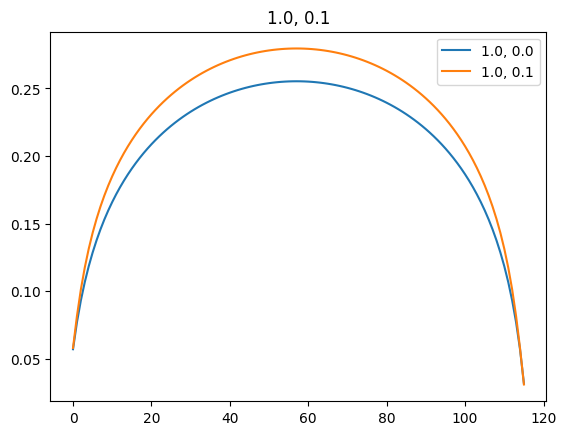

In [31]:
import os
import numpy as np
import matplotlib.pyplot as plt

# change home directory to OUT
L = 120
central_site = L//2
dir = os.path.join(os.getcwd(), f"h=1.0")

magnetization = []
magnetization2 = []
magnetization3 = []

k_values = []
h_values = []
plt.figure()

for ind, file in enumerate(sorted(os.listdir(dir), key = lambda x: float(x.split("_")[-1]))):
    name = file.split("_")
    h = float(name[1])
    k = float(name[2])

    loc = os.path.join(dir, file)

    m = np.loadtxt(os.path.join(loc, "XX.txt"), dtype=complex)
    s = np.loadtxt(os.path.join(loc, "S.txt"))
    m3 = np.loadtxt(os.path.join(loc, "X.txt")).T[1]

    # only take central ones
    indices = np.where((m[:, 0] == central_site) & (m[:,1] == central_site+1))[0]
    magnetization.append((m[indices][0][2]))
    magnetization2.append((s[central_site][1] + s[central_site+1][1] / 2))
    k_values.append(k)
    h_values.append(h)

    # entropy
    entropy1 = np.loadtxt(os.path.join(loc, "S.txt")).T[2]
    plt.plot(entropy1, label=f"{h}, {k}")
    plt.title(f"{h}, {k}")
plt.legend()
plt.show()

    # # energy
    # E = np.loadtxt(os.path.join(loc, "E_sweep.txt"))
    # plt.title(f"{h}, {k}")
    # plt.plot(np.log10(E - E[-1]))
    # plt.show()

    # # magnetization
    # plt.plot(range(len(m3)), m3)
    # plt.title("Magnetic profile")
    # plt.show()

    # # correlator:
    # mm = []
    # for i, j, corr in m:
    #     if np.abs(i - j) == 1: 
    #         mm.append(corr)
    # plt.plot(mm)

# # central magnetization
# plt.scatter(k_values, magnetization)
# plt.show()


## Magnetization

#### Magnetization of central sites against values of h/k

/home/silvanita/Desktop/thesis/master_thesis/dmrg_example/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/silvanita/Desktop/thesis/master_thesis/dmrg_example/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


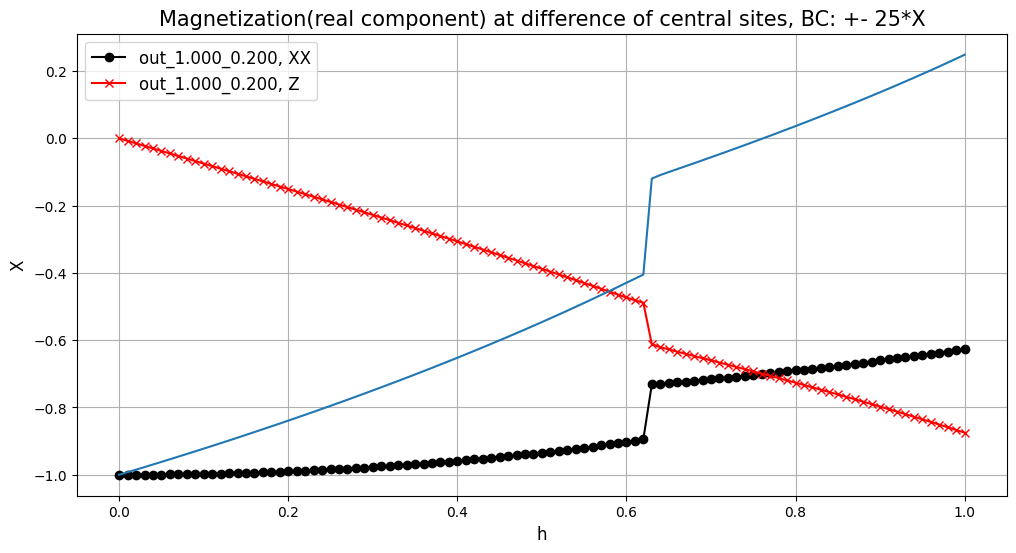

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(h_values, magnetization, c='black', marker='o', label=f"{file}, XX")
ax.plot(h_values, magnetization2, c='red', marker='x', label=f"{file}, Z")
ax.plot(h_values, np.array(magnetization) - np.array(magnetization2))

ax.set_title("Magnetization(real component) at difference of central sites, BC: +- 25*X", size=15)
ax.set_xlabel("h", size=12)
ax.set_ylabel('X', size=12)

plt.legend(fontsize=12)
plt.grid()
plt.show()

#### Magnetization along string


In [ ]:
dir = os.path.join(os.getcwd(), "k=0.5")


# colours for each one
base_cmaps = [plt.cm.Reds, plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens, plt.cm.Purples]
n_shades = 5  # number of files per block

colors = []
for integer in range(len(sorted(os.listdir(dir), key = lambda x: float(x.split("_")[-2])))):
    block = integer // n_shades              
    shade_idx = integer % n_shades           
    cmap = base_cmaps[block % len(base_cmaps)]
    
    shade = 0.3 + (0.9 - 0.3) * (shade_idx / (n_shades-1))
    colors.append(cmap(shade))

for ind, file in enumerate(sorted(os.listdir(dir), key = lambda x: float(x.split("_")[-2]))):
    fig = plt.figure(figsize=(12, 8))
    name = file.split("_")
    h = float(name[1])
    k = float(name[2])
    m2 = []

    loc = os.path.join(dir, file)

    m = np.loadtxt(os.path.join(loc, "Z.txt")).T[1]
    # m3 = np.loadtxt(os.path.join(loc, "X.txt")).T[1]
    mi = np.loadtxt(os.path.join(loc, "XX.txt"), dtype=complex)
    for i in mi:
        if np.abs(i[1] - i[0]) == 1:
            m2.append(i[2])
    m2 = np.array(m2)

    # only take central ones
    plt.scatter(range(len(m)), m, label=f"Z, h={h}")
    plt.scatter(range(len(m2)), m2, label=f"XX, h={h}")
    # plt.scatter(range(len(m3)), m3, label=f"X, h={h}")
    plt.title(f"k = {k}")
    plt.xlabel("L")
    plt.ylabel("X")
    plt.legend()
    plt.grid()
    plt.show()
    # magnetization.append((m[central_site[0]][1] - m[central_site[1]][1]))
    # k_values.append(k)
    # h_values.append(h)

#### Sanity Check - Duality of (0.5, 0.0) and (2.0, 0.0)

In [23]:
import os 
import numpy as np
import matplotlib.pyplot as plt
path = os.path.join(os.getcwd(), "DUAL")

firstX = os.path.join(path, "out_0.50_0.00", "X.txt")
secondX = os.path.join(path, "out_2.00_0.00", "X.txt")

firstXX = os.path.join(path, "out_0.50_0.00", "XX.txt")
firstZ = os.path.join(path, "out_0.50_0.00", "Z.txt")
secondXX = os.path.join(path, "out_2.00_0.00", "XX.txt")
secondZ = os.path.join(path, "out_2.00_0.00", "Z.txt")

readxx1, readxx2 = np.loadtxt(firstXX, dtype=complex), np.loadtxt(secondXX, dtype=complex)
XX1, XX2 = [], []
for entry in readxx1:
    if entry[1] - entry[0] == 1:
        XX1.append(entry[2])

for entry in readxx2:
    if entry[1] - entry[0] == 1:
        XX2.append(entry[2])

Z1, Z2 = np.loadtxt(firstZ, dtype=complex).T[1], np.loadtxt(secondZ, dtype=complex).T[1]

X1, X2 = np.loadtxt(firstX, dtype=complex).T[1], np.loadtxt(secondX, dtype=complex).T[1]


/home/silvanita/Desktop/thesis/master_thesis/dmrg_example/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/silvanita/Desktop/thesis/master_thesis/dmrg_example/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


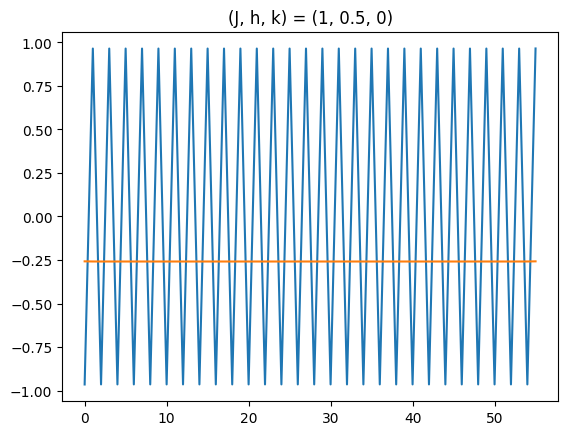

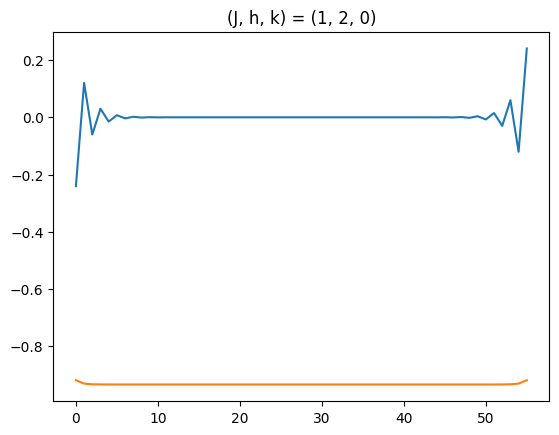

In [25]:
plt.plot(X1)
plt.plot(Z1)
plt.title("(J, h, k) = (1, 0.5, 0)")
plt.show()

plt.plot(X2)
plt.plot(Z2)
plt.title("(J, h, k) = (1, 2, 0)")
plt.show()

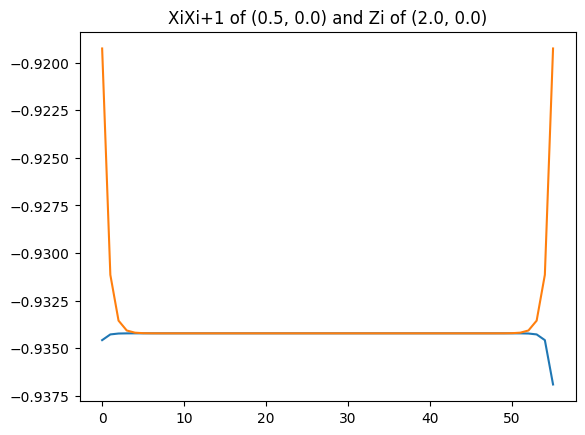

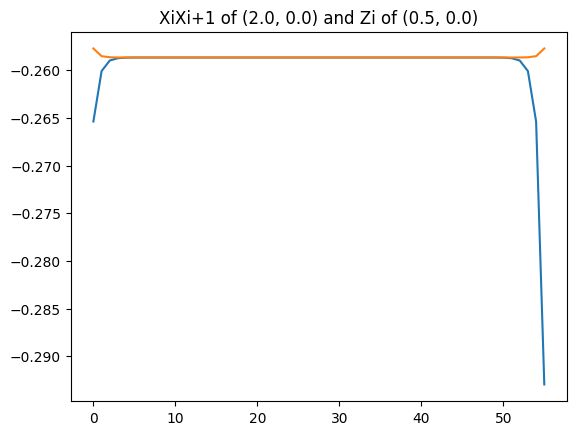

In [27]:

plt.plot(XX1)
plt.plot(Z2)
plt.title("XiXi+1 of (0.5, 0.0) and Zi of (2.0, 0.0)")
plt.show()

plt.plot(XX2)
plt.plot(Z1)
plt.title("XiXi+1 of (2.0, 0.0) and Zi of (0.5, 0.0)")
plt.show()


## Correlations

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from numpy import fft as fft
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

L = 200
cut = L//2
line = "h0_af_polbc_step0.01"
path = os.path.join(os.getcwd(), line)


#### Correlation function
The next code works on plotting connected correlations
 $$ C(x_i, x_j) = \langle x_i x_j \rangle - \langle x_i\rangle\langle x_j\rangle$$
By comparing them against semilogy and log log plots, we can determine if the phase we are looking at is gapped or gapless

/tmp/ipykernel_20604/4105288277.py:57: ComplexWarning: Casting complex values to real discards the imaginary part
  correlation = np.array(correlation, dtype=float)


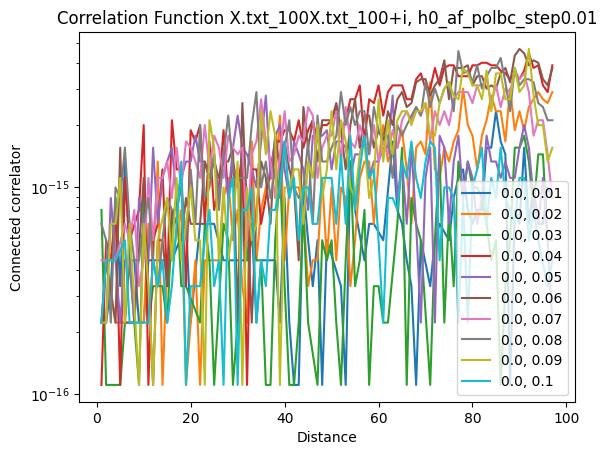

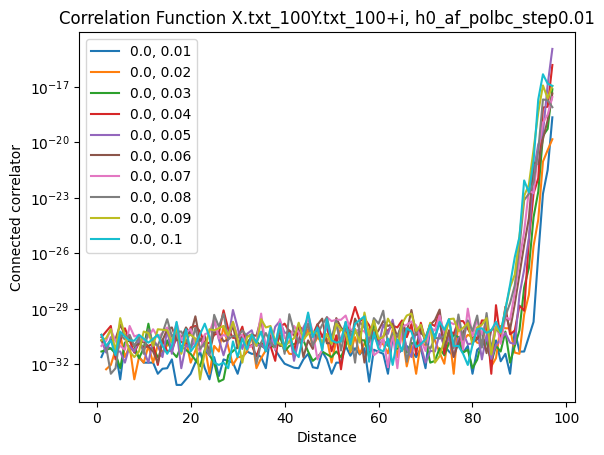

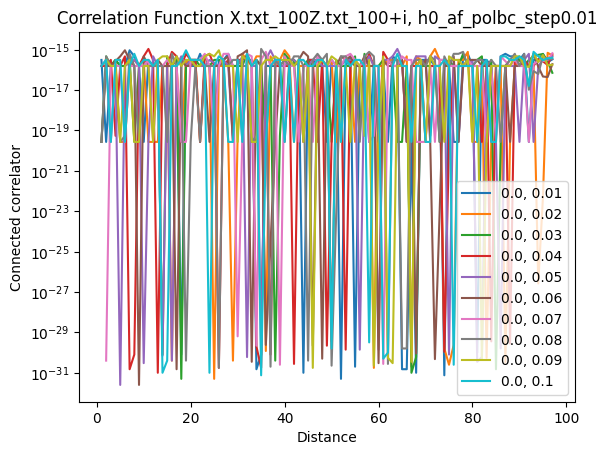

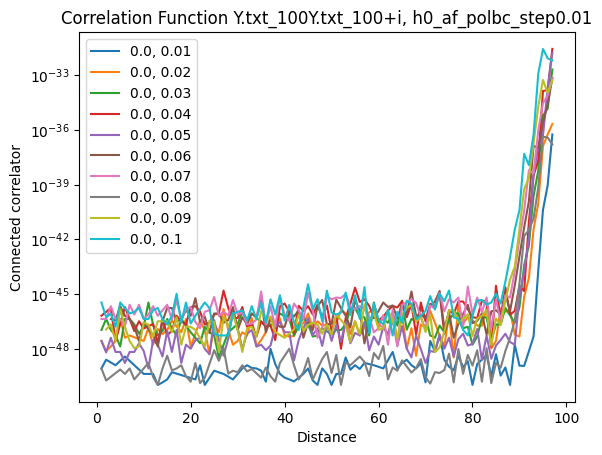

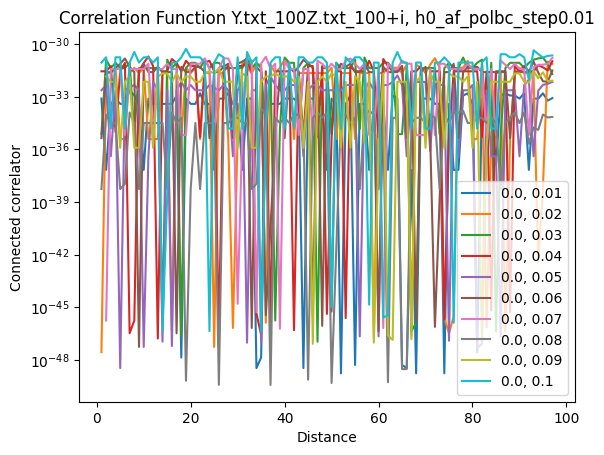

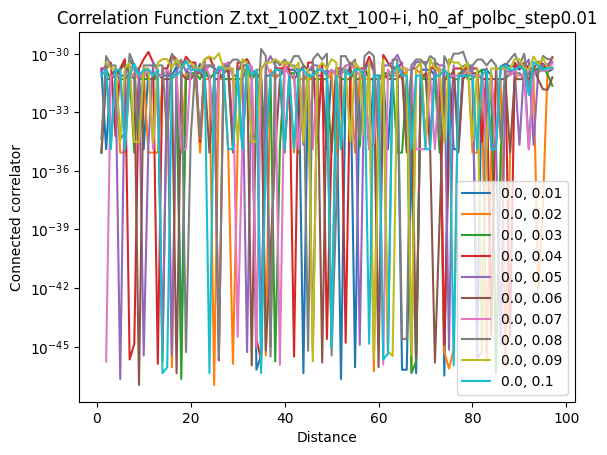

In [16]:
from itertools import combinations_with_replacement

# Paths
files = sorted(os.listdir(os.path.join(path)))
base_cmaps = [plt.cm.Reds, plt.cm.Blues, plt.cm.Greens, plt.cm.Oranges, plt.cm.Purples]
n_shades = 5  # number of files per block

# colours
colors = []
for i in range(len(files)):
    block = i // n_shades              
    shade_idx = i % n_shades           
    cmap = base_cmaps[block % len(base_cmaps)]
    
    shade = 0.3 + (0.9 - 0.3) * (shade_idx / (n_shades - 1))
    colors.append(cmap(shade))

# function to fit
def linfun(x, m, c):
    return m * x + c

exponent_semi = []
exp_err_semi = []
exponent_log = []
exp_err_log = []

corr_i, corr_j = "X" , "X"

cor1 = ['X', 'Y', 'Z']
combo = [[i+".txt", j+".txt", i+j+".txt"] for i, j in combinations_with_replacement(cor1, 2)]

for combi in combo:
    for count, file in enumerate(sorted(os.listdir(path))):
        h = float(file.split("_")[1])
        k = float(file.split("_")[2])
        filename = os.path.join(path, f"out_{h:.3f}_{k:.3f}")
        
        xx_values = np.loadtxt(os.path.join(filename, combi[2]), dtype=complex)
        i_values = np.loadtxt(os.path.join(filename, combi[0]), dtype=complex).T
        j_values = np.loadtxt(os.path.join(filename, combi[1]), dtype=complex).T

        distance = []
        correlation = []
        for i, j, corr in xx_values:
            if i==cut and j < L-2:
                dist = np.abs(j - i)
                
                xi = np.where(np.isclose(i_values[0], i, atol=1e-8))[0]
                xj = np.where(np.isclose(j_values[0], j, atol=1e-8))[0]
                staggered_corr = (np.real(corr) - (i_values[1][xi] * j_values[1][xj]))[0]
                # staggered_corr = corr

                correlation.append(staggered_corr)
                distance.append(dist)

        distance = np.array(distance, dtype=int)
        correlation = np.array(correlation, dtype=float)

        zerod_out = ((np.abs(correlation) > 1e-50) & (np.isfinite(correlation)))
        distance = distance[zerod_out]
        correlation = correlation[zerod_out]
        # print(f"{correlation.shape}")
        plt.semilogy(distance, np.abs(correlation), label=f"{h}, {k}")
        plt.title(f"Correlation Function {combi[0]}_{cut}{combi[1]}_{cut}+i, {line}")
        plt.grid()
        plt.legend()
        plt.ylabel("Connected correlator")
        plt.xlabel("Distance")
    plt.show()

# plt.tight_layout()
# plt.show()


#### Fourier Transform - $q_L$

In the search for incommensurability, it is useful to look for the primary frequency of the oscillations of our function. To do this, we take the fourier transform of our correlation function and look for frequencies that do not align with the lattice of our system i.e. $\phi \not\in \{0, \pi\}$.

/home/silvanita/Desktop/thesis/master_thesis/books/inbetween


/tmp/ipykernel_10699/3808309888.py:46: ComplexWarning: Casting complex values to real discards the imaginary part
  correlation = np.array(correlation, dtype=float)


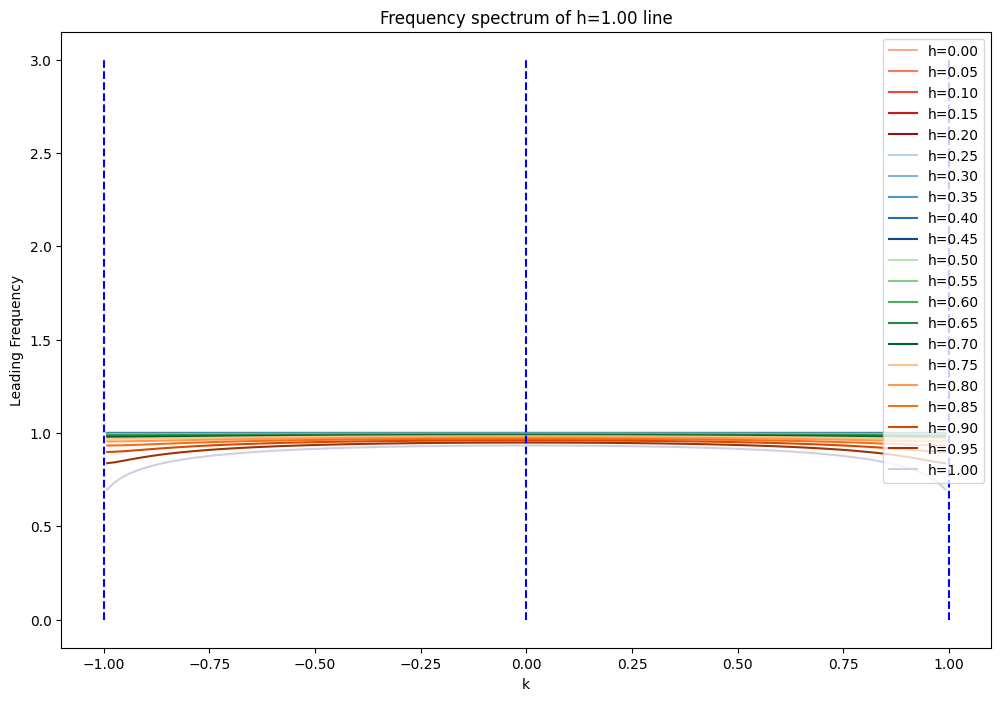

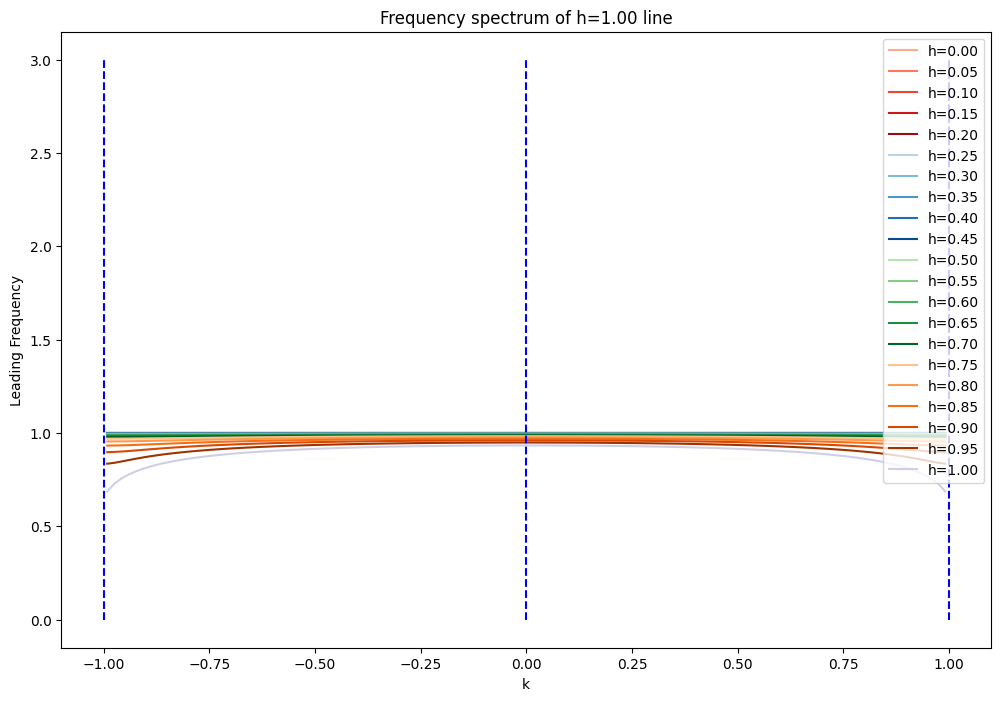

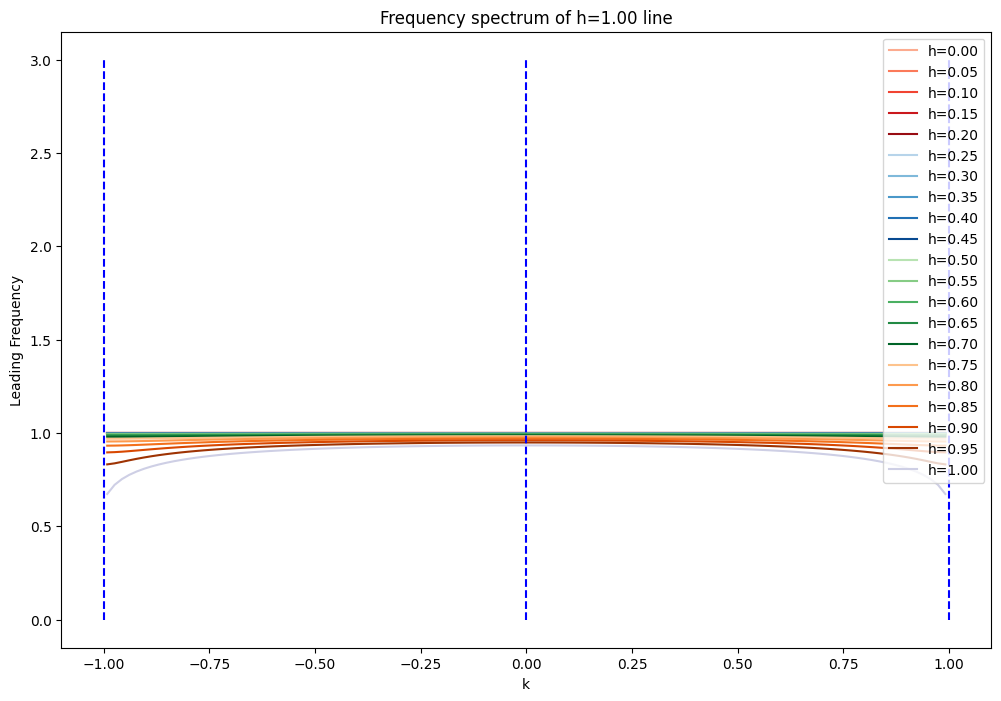

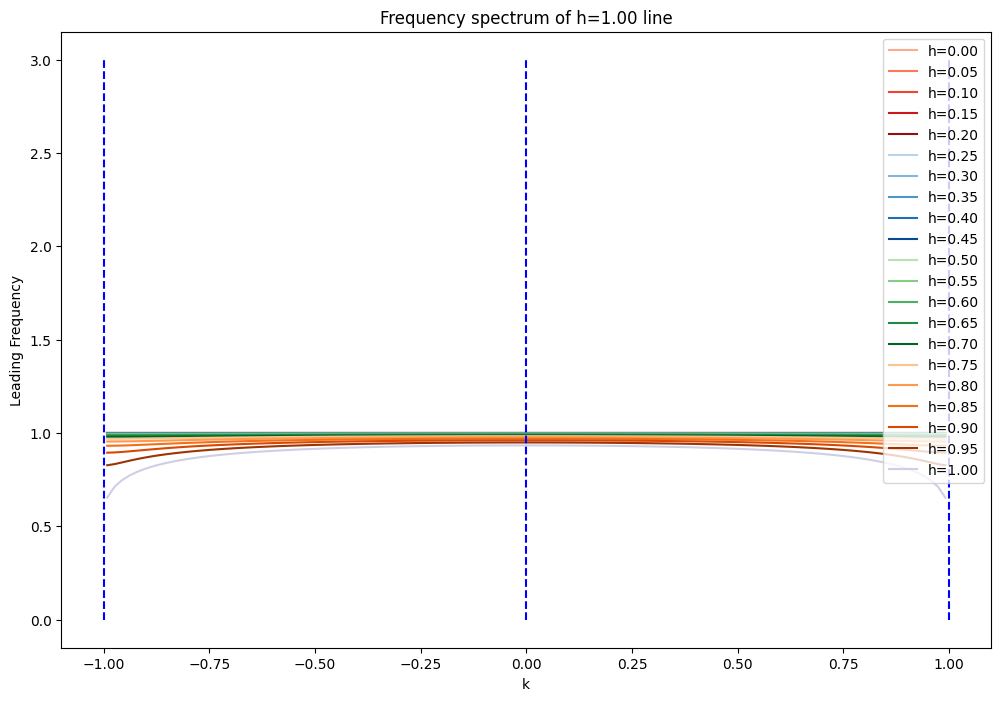

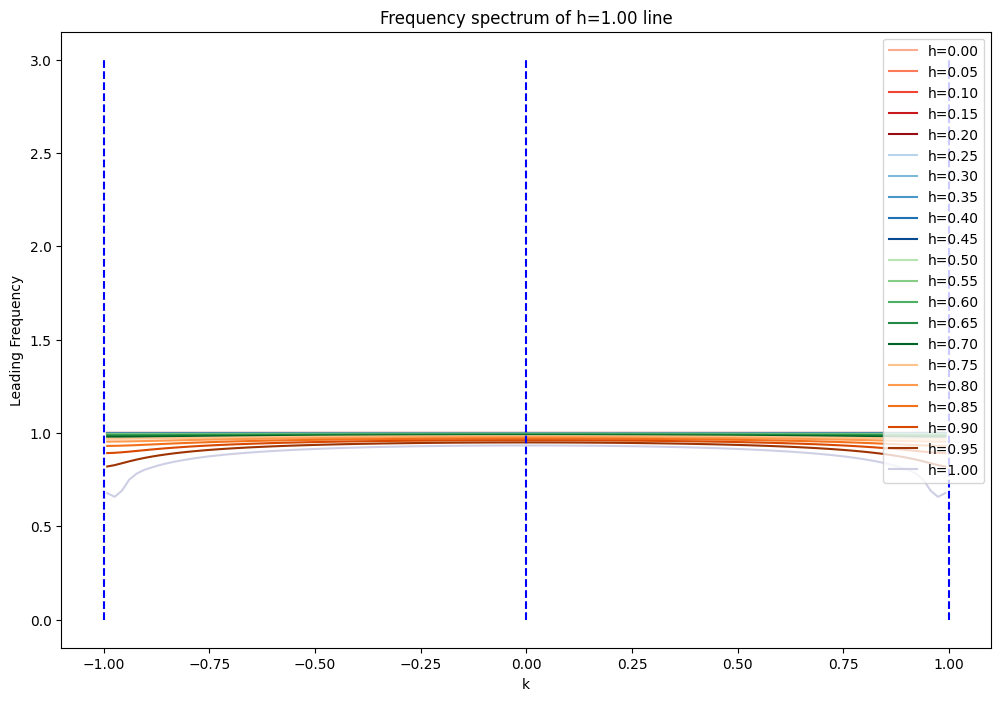

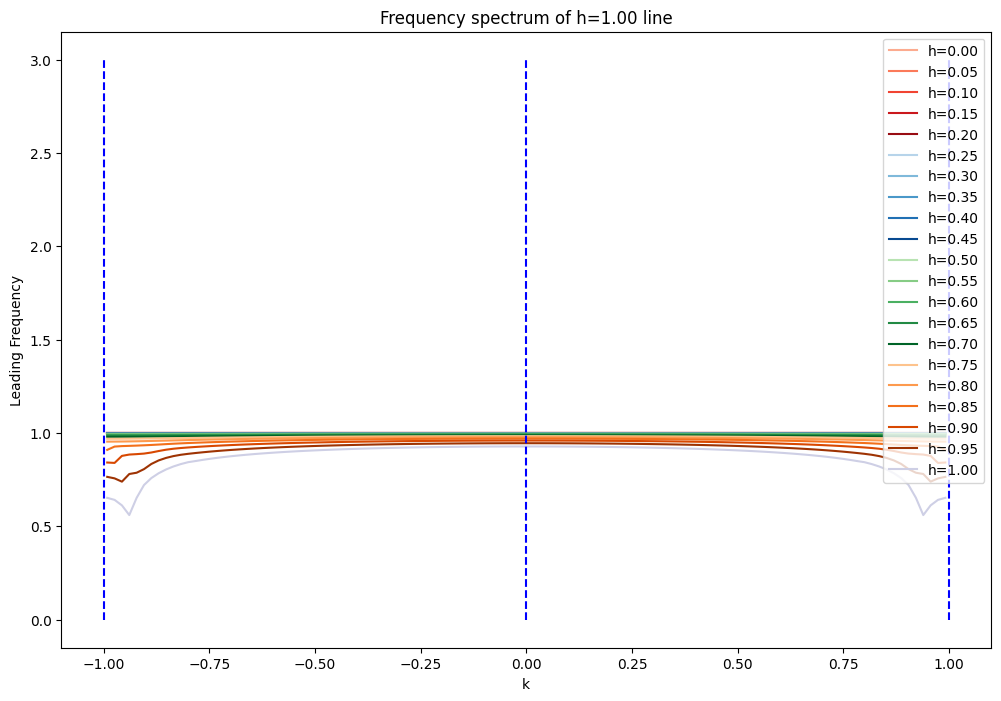

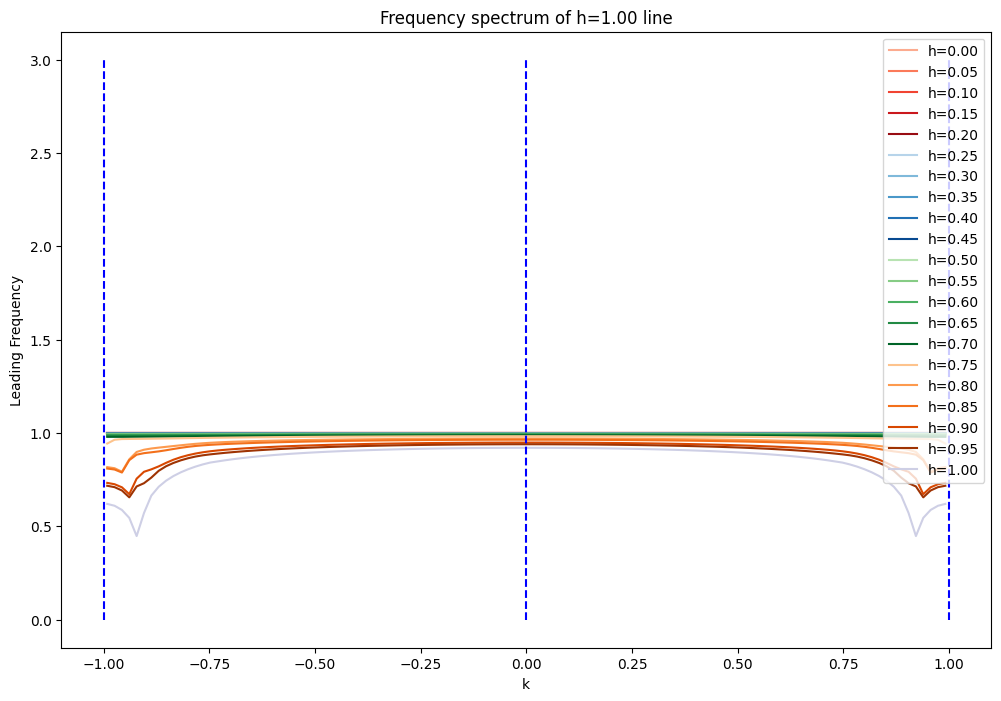

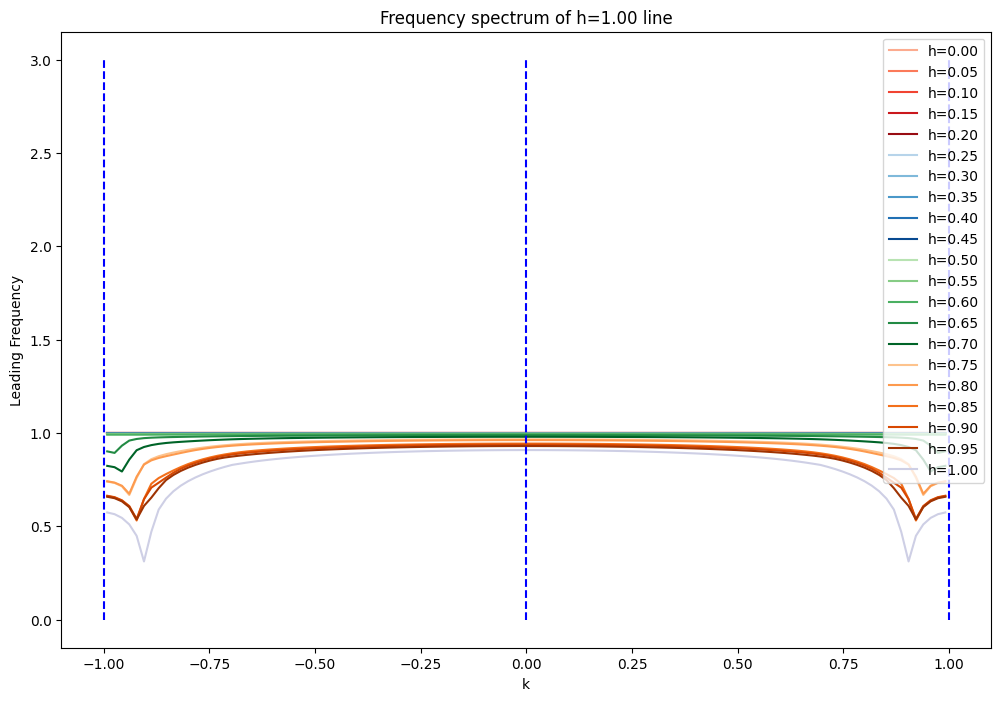

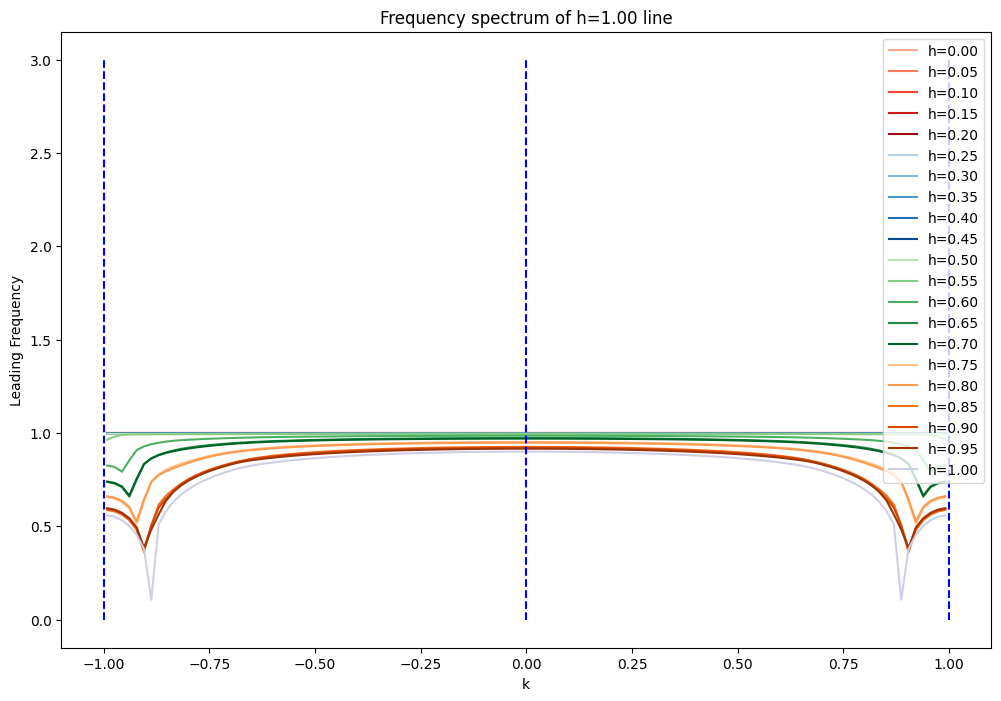

In [ ]:
from scipy.signal import find_peaks

print(path)
for ll in sorted(os.listdir(path)):
    colors = []
    ks = []
    omega = []
    fig = plt.figure(figsize=(12, 8))

    files = sorted(os.listdir(os.path.join(path, ll)))
    base_cmaps = [plt.cm.Reds, plt.cm.Blues, plt.cm.Greens, plt.cm.Oranges, plt.cm.Purples]
    n_shades = 5  # number of files per block

    # colours
    colors = []
    for i in range(len(files)):
        block = i // n_shades              
        shade_idx = i % n_shades           
        cmap = base_cmaps[block % len(base_cmaps)]
        
        shade = 0.3 + (0.9 - 0.3) * (shade_idx / (n_shades - 1))
        colors.append(cmap(shade))

    for count, file in enumerate(sorted(os.listdir(os.path.join(path, ll)))):
        h = float(file.split("_")[1])
        k = float(file.split("_")[2])
        ks.append(h)
        filename = os.path.join(path, ll, f"out_{h:.2f}_{k:.2f}")
        xx_values = np.loadtxt(os.path.join(filename, "XX.txt"), dtype=complex)
        i_values = np.loadtxt(os.path.join(filename, 'X.txt'), dtype=complex).T

        distance = []
        correlation = []
        for i, j, corr in xx_values:
            if i == cut and j < L-2:
                dist = np.abs(j - i)
                distance.append(dist)
                xi = np.where(np.isclose(i_values[0], i, atol=1e-8))[0][0]
                xj = np.where(np.isclose(i_values[0], j, atol=1e-8))[0][0]

                # Staggered correlation
                staggered_corr = corr - (i_values[1][xi] * i_values[1][xj])
                correlation.append(staggered_corr)

        distance = np.array(distance, dtype=int)
        correlation = np.array(correlation, dtype=float)

        # Average correlations by distance
        groups = defaultdict(list)
        for d, c in zip(distance, correlation):
            groups[d].append(c)
        d_vals = np.array(sorted(groups.keys()))
        avg_corr = np.array([np.mean(groups[d]) for d in d_vals])

        # Fourier transform
        corr_fft = np.fft.fftshift(np.fft.fft(correlation))
        freqs = np.fft.fftshift(np.fft.fftfreq(len(correlation), d=1)) * 2
        plt.plot(freqs, np.abs(corr_fft), color=colors[count], label=f"h={h:.2f}")

    plt.xlabel("k")
    plt.ylabel("Leading Frequency")
    plt.vlines([0, 1, -1], 0, 3, colors='b', linestyles='--')
    plt.title(f"Frequency spectrum of h={h:.2f} line")
    plt.legend()
    plt.show()


/tmp/ipykernel_10699/250484258.py:46: ComplexWarning: Casting complex values to real discards the imaginary part
  correlation = np.array(correlation, dtype=float)


[]
0
[]
0
[]
0
[]
0
[0.97391304]
0
[0.97391304 0.95652174 0.93913043]
0
[0.95652174 0.95652174 0.93913043 0.93913043 0.92173913]
0
[0.97391304 0.95652174 0.93913043 0.93913043 0.92173913 0.92173913
 0.92173913 0.90434783]
0
[0.95652174 0.93913043 0.93913043 0.92173913 0.92173913 0.90434783
 0.90434783 0.90434783 0.88695652]
0


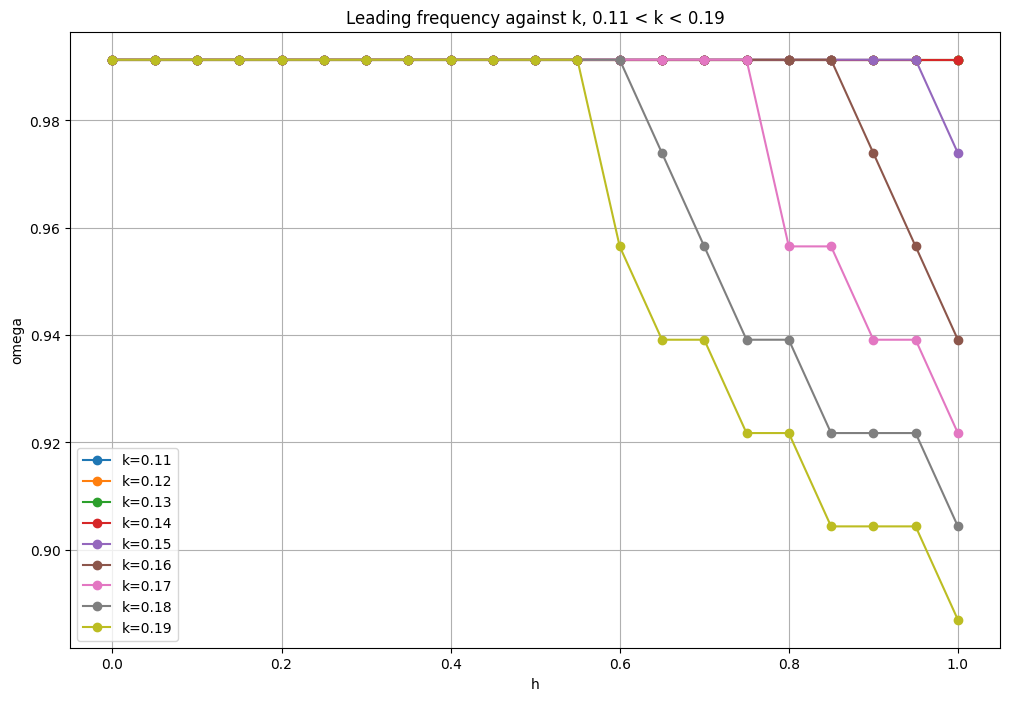

ValueError: x and y must have same first dimension, but have shapes (21,) and (0,)

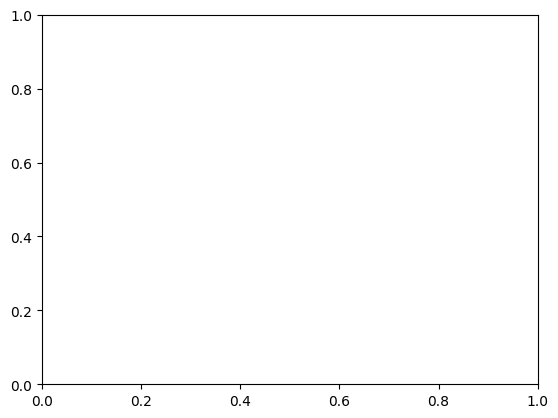

In [ ]:
fig = plt.figure(figsize=(12, 8))


for ll in sorted(os.listdir(path)):
    colors = []
    ks = []
    omega = []
    deviation = []

    files = sorted(os.listdir(os.path.join(path, ll)))
    base_cmaps = [plt.cm.Reds, plt.cm.Blues, plt.cm.Greens, plt.cm.Oranges, plt.cm.Purples]
    n_shades = 5  # number of files per block

    # colours
    colors = []
    for i in range(len(files)):
        block = i // n_shades              
        shade_idx = i % n_shades           
        cmap = base_cmaps[block % len(base_cmaps)]
        
        shade = 0.3 + (0.9 - 0.3) * (shade_idx / (n_shades - 1))
        colors.append(cmap(shade))

    for count, file in enumerate(sorted(os.listdir(os.path.join(path, ll)))):
        h = float(file.split("_")[1])
        k = float(file.split("_")[2])
        ks.append(h)
        filename = os.path.join(path, ll, f"out_{h:.2f}_{k:.2f}")
        xx_values = np.loadtxt(os.path.join(filename, "XX.txt"), dtype=complex)
        i_values = np.loadtxt(os.path.join(filename, 'X.txt'), dtype=complex).T

        distance = []
        correlation = []
        for i, j, corr in xx_values:
            if i == cut and j < L-2:
                dist = np.abs(j - i)
                distance.append(dist)
                xi = np.where(np.isclose(i_values[0], i, atol=1e-8))[0][0]
                xj = np.where(np.isclose(i_values[0], j, atol=1e-8))[0][0]

                # Staggered correlation
                staggered_corr = corr - (i_values[1][xi] * i_values[1][xj])
                correlation.append(staggered_corr)

        distance = np.array(distance, dtype=int)
        correlation = np.array(correlation, dtype=float)



        # Fourier transform
        corr_fft = np.fft.fftshift(np.fft.fft(correlation))
        freqs = np.fft.fftshift(np.fft.fftfreq(len(correlation), d=1)) * 2

        correlation = np.abs(corr_fft)
        idx = np.argmax(correlation[freqs > 0])
        idx_global = np.arange(len(correlation))[freqs > 0][idx]
        omega.append(freqs[idx_global])
    omega = np.array(omega)
    dev = np.array(omega)-omega[0] < 0
    print(omega[dev])
    if len(omega[dev]) > 0:
        print(np.argmax(omega[dev])[0])
    else:
        print("0")

    
    plt.plot(ks, np.array(omega), '-o', label = f"k={k}")
    plt.title(f"Leading frequency against k, 0.11 < k < 0.19")
    plt.xlabel("h")
    plt.ylabel("omega")

    

plt.grid()
plt.legend()
plt.show()

plt.plot(ks, deviation)
plt.show()

#### Correlation function fitting  - $q_R$

/tmp/ipykernel_6019/3784410489.py:40: ComplexWarning: Casting complex values to real discards the imaginary part
  correlation = np.array(correlation[cut:-cut], dtype=float)


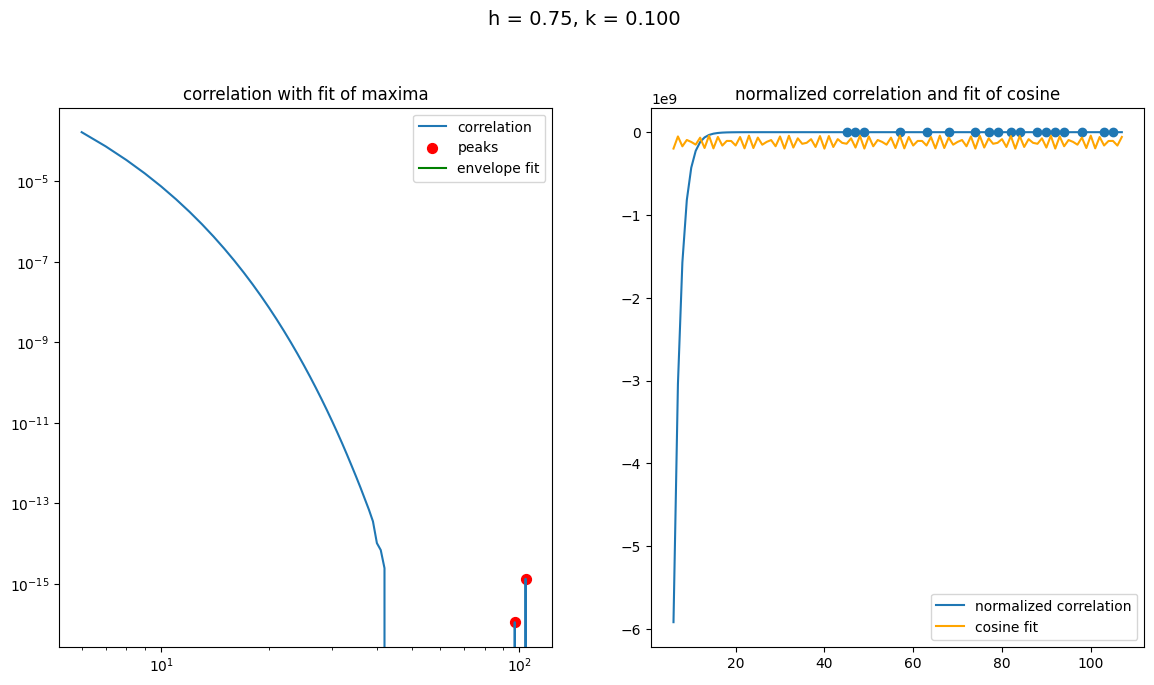

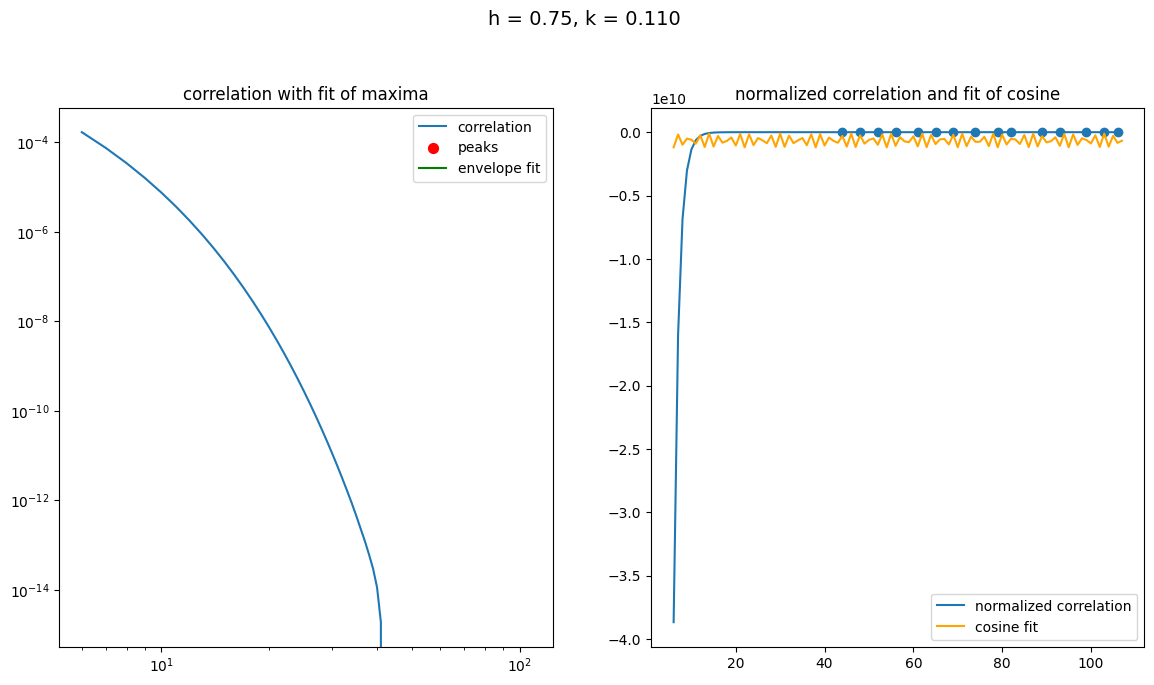

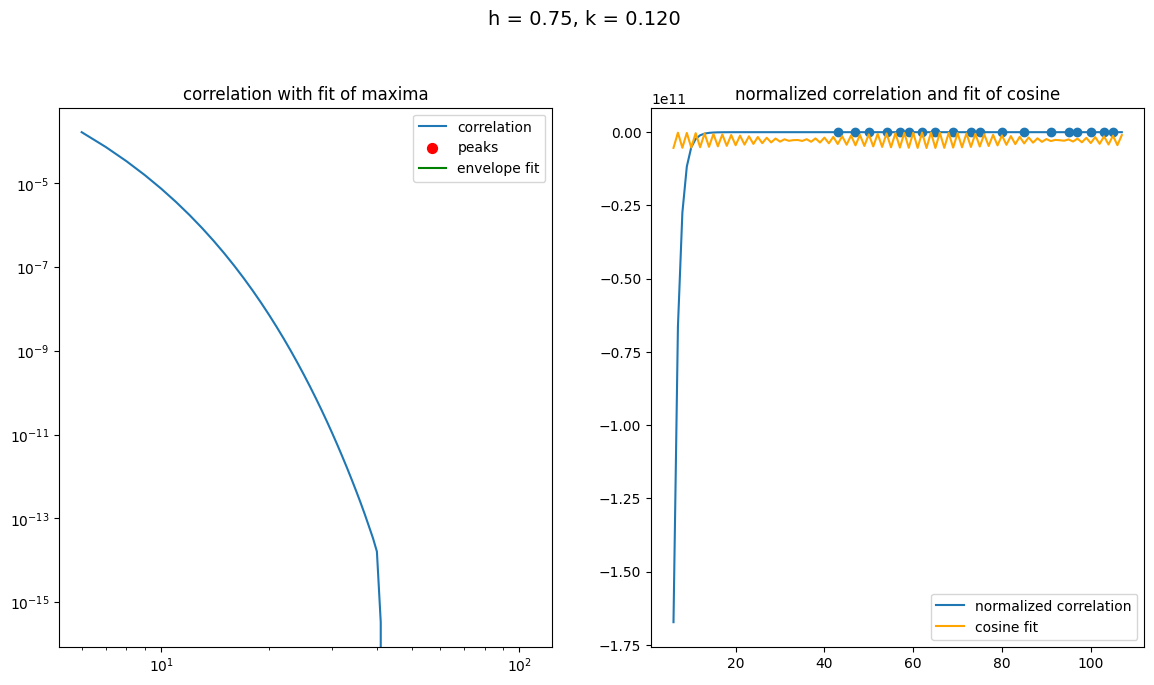

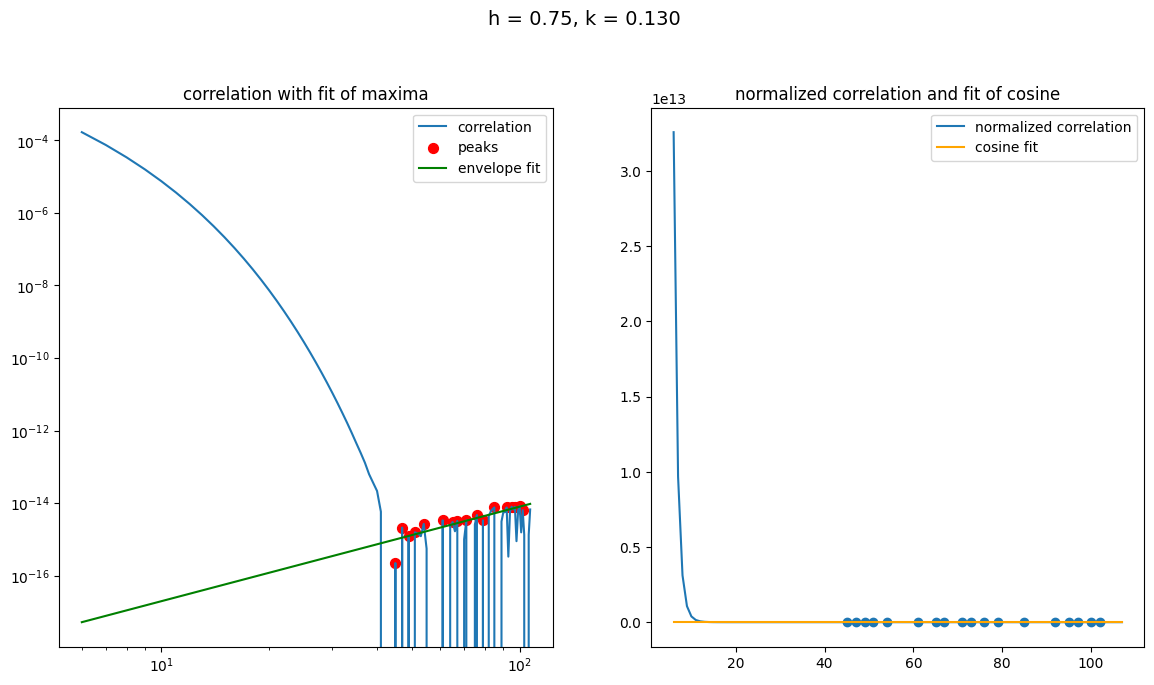

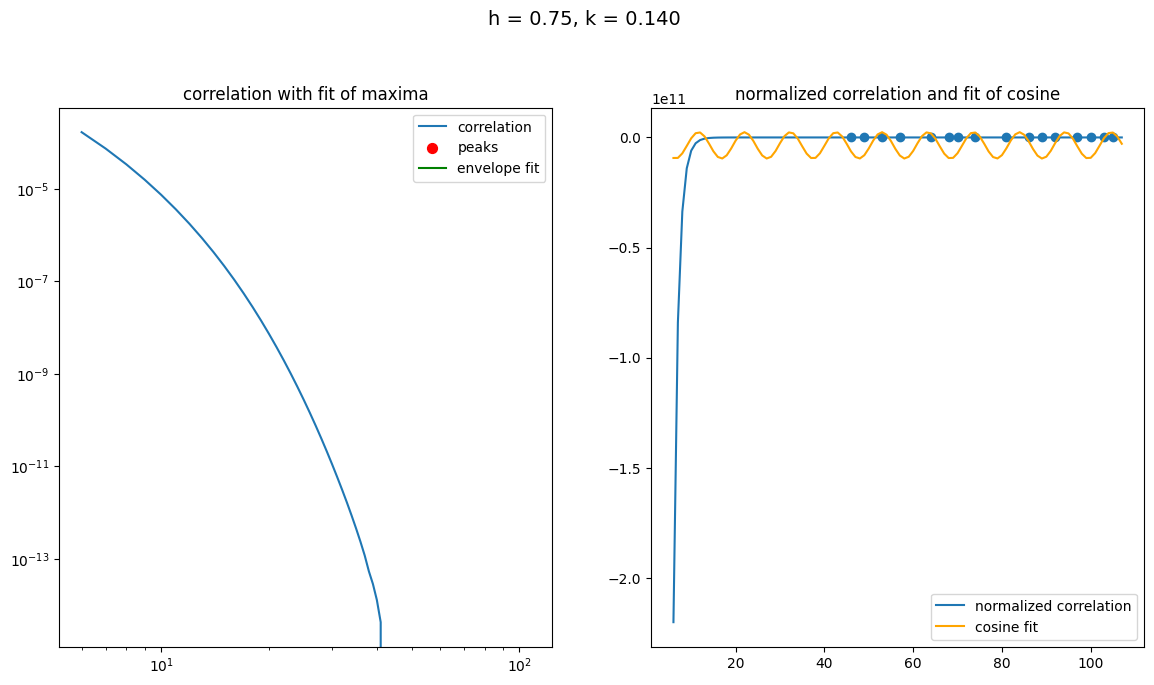

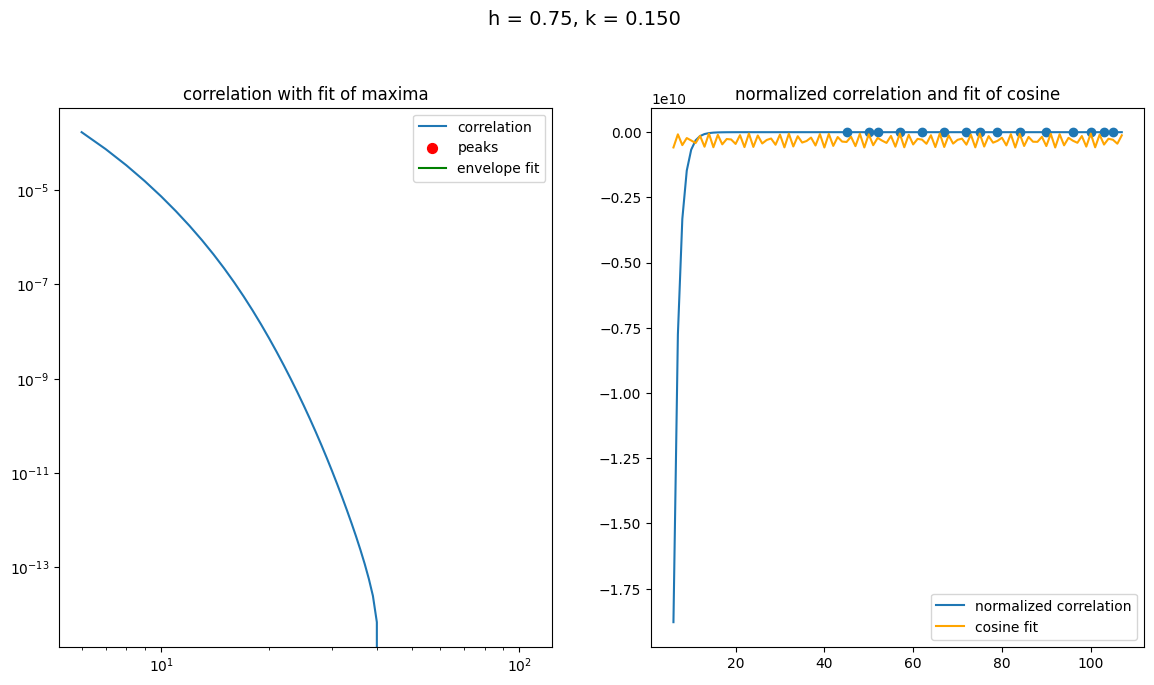

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 1000.

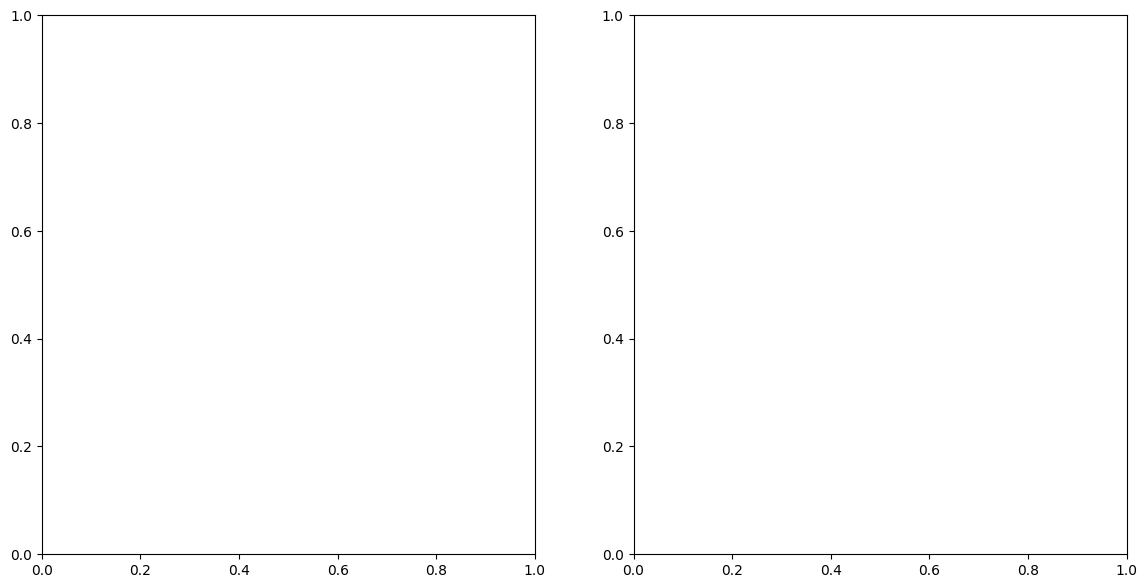

In [ ]:
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

def linfun(x, A, c):
    return A * x + c

def power(x, A, xi):
    return A * x ** (-xi)

def coswave(x, A, q, phi, c):
    return A * np.cos(q * x + phi) + c

files = sorted(os.listdir(path))

for count, file in enumerate(files):
    h = float(file.split("_")[1])
    k = float(file.split("_")[2])
    filename = os.path.join(path, f"out_{h:.3f}_{k:.3f}")
    xx_values = np.loadtxt(os.path.join(filename, "XX.txt"), dtype=complex)
    i_values = np.loadtxt(os.path.join(filename, 'X.txt'), dtype=complex).T

    fig, ax = plt.subplots(1, 2, figsize=(14, 7))

    distance = []
    correlation = []

    for i, j, corr in xx_values:
        if i == cut and j < L-2:
            dist = np.abs(j - i)
            xi = np.where(np.isclose(i_values[0], i, atol=1e-8))[0][0]
            xj = np.where(np.isclose(i_values[0], j, atol=1e-8))[0][0]
            staggered_corr = ((-1)**dist) * (corr - (i_values[1][xi] * i_values[1][xj]))
            
            distance.append(dist)
            correlation.append(staggered_corr)

    cut = 5
    distance = np.array(distance[cut:-cut], dtype=int)
    correlation = np.array(correlation[cut:-cut], dtype=float)

    peaks, _ = find_peaks(correlation)
    if len(correlation[peaks]) != 0:
        popt_env, pcov_env = curve_fit(power, distance[peaks], correlation[peaks])
    else:
        popt_env, pcov_env = curve_fit(power, distance, correlation)
    envelope = power(distance, *popt_env)

    fixed_corr = correlation / envelope

    # Fit cosine to normalized data
    # p0 = [np.max(fixed_corr)-np.min(fixed_corr), 2 * np.pi * (distance[peaks_cos][1] - distance[peaks_cos][0]), 0, 0]  # amplitude, freq, phase, offset
    popt_cos, _ = curve_fit(coswave, distance, fixed_corr)
    peaks_cos, _ = find_peaks(fixed_corr)
    # xis.append(popt_env[1])
    # xis_error.append(np.array(pcov_env[1][1]) ** 0.5)
    # ks.append(k)

# plt.errorbar(ks, xis, xis_error)
# plt.xlabel("k")
# plt.ylabel("xis")

    # Plot correlation + envelope fit
    ax[0].loglog(distance, correlation, label="correlation")
    ax[0].scatter(distance[peaks], correlation[peaks], color='red', s=50, label="peaks")
    ax[0].loglog(distance, envelope, color='green', label="envelope fit")
    ax[0].set_title("correlation with fit of maxima")
    ax[0].set_ylim(auto=True)
    ax[0].legend()

    # Plot normalized correlation + cosine fit (linear)
    ax[1].plot(distance, fixed_corr, label="normalized correlation")
    ax[1].scatter(distance[peaks_cos], fixed_corr[peaks_cos])
    ax[1].plot(distance, coswave(distance, *popt_cos), label="cosine fit", color='orange')
    ax[1].set_title("normalized correlation and fit of cosine")
    ax[1].legend()
    ax[1].set_ylim(auto=True)


    fig.suptitle(f"h = {h:.2f}, k = {k:.3f}", fontsize=14, y=1.02)
    plt.show()


#### Fitting $\xi$ to find critical exponent $\nu$




Now that we have begun plotting the correlation function, it is simple to find the correlation length, via the exponential decay formula $\langle X_iX_{i+1}\rangle \propto e^{{-\frac{r}{\xi}}}$, which results in the following equation for a semilogy plot: $ \log{\langle X_i X_{i+1} \rangle} \propto -\frac{1}{\xi} r $ for gapped phases and algebraic/power law decay $\langle X_iX_{i+1}\rangle \propto |i - j| ^ {-\eta}$ for gapless.
We can plot the correlation function on a semilog-y and fit it to a linear function to find correlation length $\xi$ on the slope. After finding the correlation length, we can also determine a special critical exponent $$ \xi \propto |k - k_c|^{-\nu}$$ for some critical $k_c$ value along a "vertical cut" (keeping h constant, varying k). We know this is theoretically $\nu = 1/2$, so we try to fit $-1/v = -2$ $$ \xi ^ {-1/v} = A|k - k_c|+c $$ and see how well this fits.


/tmp/ipykernel_9207/1569433264.py:79: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


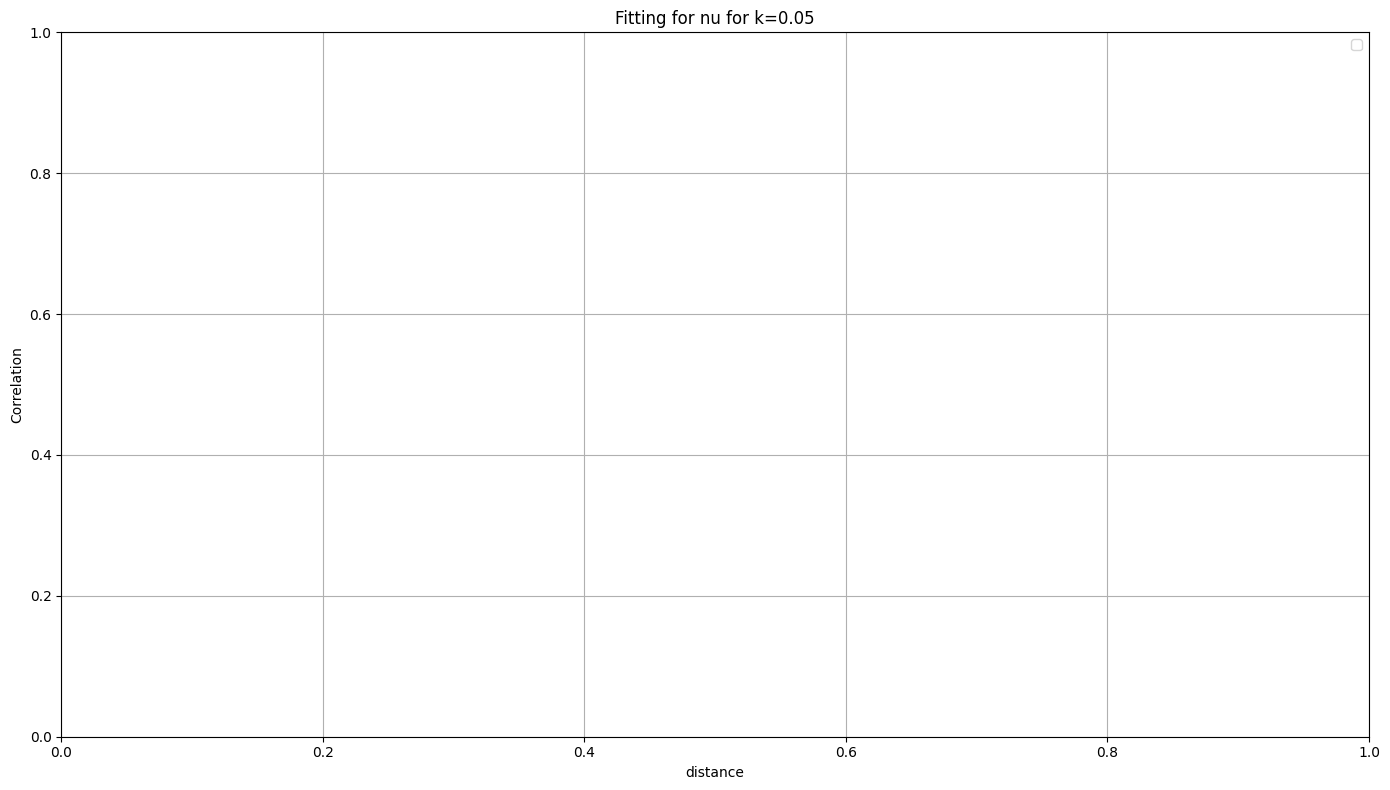

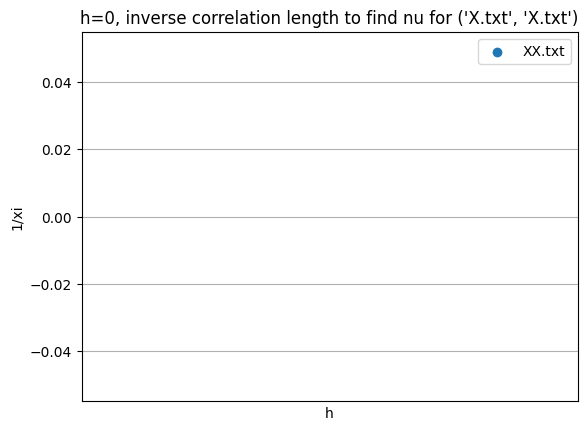

In [45]:
import os
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations_with_replacement

combo = [['X.txt', 'X.txt', 'XX.txt']]

# Paths
files = sorted(os.listdir(os.path.join(path)))

# function to fit
def linfun(x, m, c):
    return m * x + c

for corr_i, corr_j, combi in combo:

    xis = []
    ks=[]

    plt.figure(figsize=(14, 8))
    plt.ylabel("Correlation")
    plt.xlabel("distance")
    plt.title(f"Fitting for nu for k={k}")
    for count, file in enumerate(sorted(os.listdir(path))):
        h = float(file.split("_")[1])
        k = float(file.split("_")[2])
        filename = os.path.join(path, f"out_{h:.3f}_{k:.3f}")
        xx_values = np.loadtxt(os.path.join(filename, combi), dtype=complex)
        i_values = np.loadtxt(os.path.join(filename, corr_i), dtype=complex).T
        j_values = np.loadtxt(os.path.join(filename, corr_j), dtype=complex).T
        distance = []
        correlation = []
        for i, j, corr in xx_values:
            if i == cut and j < L - 2:
                dist = np.abs(j - i)
                distance.append(dist)
                xi = np.where(np.isclose(i_values[0], i, atol=1e-8))[0]
                xj = np.where(np.isclose(j_values[0], j, atol=1e-8))[0]
                
                staggered_corr = np.real(corr)- np.real(i_values[1][xi]*j_values[1][xj])
                correlation.append(staggered_corr[0])
                
        distance = np.array(distance, dtype=int)
        correlation = np.array(correlation, dtype=float)

        if len(distance) > 1 and len(correlation) > 1:
            sorted_idx = np.argsort(distance)
            distance = distance[sorted_idx]
            correlation = correlation[sorted_idx]

            zerod_out = ((np.abs(correlation) > 5e-14) & (np.isfinite(correlation)))
            distance = distance[zerod_out]
            correlation = correlation[zerod_out]

            frac = 0.6
            n_points = len(distance)
            start_idx = int(n_points * (1 - frac) / 2)
            end_idx = int(n_points * (1 + frac) / 2)
            
            if start_idx == end_idx:
                start_idx = max(0, start_idx-1)
                end_idx = min(n_points, end_idx+1)

            central_distance = distance[start_idx:end_idx]
            central_correlation = correlation[start_idx:end_idx]

            if len(central_distance) > 1:
                popt, pcov = curve_fit(linfun, central_distance, np.log10(np.abs(central_correlation)))
                plt.scatter(distance, np.log10(np.abs(correlation)))
                plt.plot(distance, linfun(distance, *popt), label=f"{h}")
        
                # add correlation
                xis.append(-1/popt[0])
                ks.append(h)

    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Define k values
    # step = 0.1
    # ks = np.arange(0, 1+step, step)

    # Select a region where xi(k) looks linear
    start, end = 0, -1   # adjust manually
    ks_straight = ks[start:end]
    xis_straight = np.array(xis[start:end])

    # Plot
    plt.scatter(ks_straight, 1/xis_straight, label=f"{combi}")
    plt.xlabel("h")
    plt.ylabel("1/xi")
    plt.title(f"{line}, inverse correlation length to find nu for {corr_i,corr_j}")
    plt.xticks(ks[::2])
    plt.legend()

plt.grid()
plt.show()


 To make sure we check for all possible outcomes, we make a loop here to look at all potential two point correlators. Here we will only plot the final $\frac{1}{\xi}$ against the parameter of choice (either h or k)

/tmp/ipykernel_19030/3855726805.py:84: RuntimeWarning: invalid value encountered in log
  plt.plot(ks_straight, np.log(1/xis_straight), label=f"{combi}")


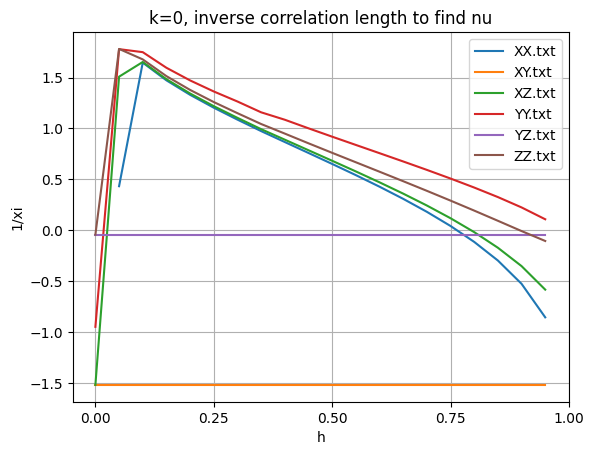

In [101]:
import os
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations_with_replacement

cor1 = ['X', 'Y', 'Z']
combo = [[i+".txt", j+".txt", i+j+".txt"] for i, j in combinations_with_replacement(cor1, 2)]

# Paths
files = sorted(os.listdir(os.path.join(path)))
# cuts = 10
# function to fit
def linfun(x, m, c):
    return m * x + c


for corr_i, corr_j, combi in combo:
    xis = []
    ks=[]

    for count, file in enumerate(sorted(os.listdir(path))):
        h = float(file.split("_")[1])
        k = float(file.split("_")[2])
        filename = os.path.join(path, f"out_{h:.3f}_{k:.3f}")
        xx_values = np.loadtxt(os.path.join(filename, combi), dtype=complex)
        i_values = np.loadtxt(os.path.join(filename, corr_i), dtype=complex).T
        j_values = np.loadtxt(os.path.join(filename, corr_j), dtype=complex).T
        distance = []
        correlation = []
        for i, j, corr in xx_values:
            if i == cut and j < L - 2:
                dist = np.abs(j - i)
                distance.append(dist)
                xi = np.where(np.isclose(i_values[0], i, atol=1e-8))[0]
                xj = np.where(np.isclose(j_values[0], j, atol=1e-8))[0]
                
                staggered_corr = corr - ((i_values[1][xi]) * (j_values[1][xj]))
                correlation.append(np.abs(staggered_corr[0]))

        distance = np.array(distance, dtype=int)
        correlation = np.array(correlation, dtype=float)
    

        zerod_out = (np.abs(correlation) > 1e-15) & (np.isfinite(correlation))
        distance = distance[zerod_out]
        correlation = correlation[zerod_out]

        # plot against exponential

        if len(distance) > 1:
            popt, pcov = curve_fit(linfun, distance[:5], np.log(np.abs(correlation[:5])))
        # else:
            # print("Not enough valid data points for fitting.")

        # plt.scatter(distance, np.log(np.abs(correlation)))
        # plt.plot(distance[:10], linfun(distance[:10], *popt))
        # plt.ylabel("Correlation")
        # plt.xlabel("distance")
        # plt.title(f"Fitting for nu for h={h}, k={k}")
        # plt.tight_layout()
        # plt.show()

        # add correlation
        xis.append(-1/popt[0])
        ks.append(h)


    # Define k values
    # step=0.005
    # ks = np.arange(0.4, 0.6+step, step)

    # Select a region where xi(k) looks linear
    start, end = 0, -1   # adjust manually
    ks_straight = ks[start:end]
    xis_straight = np.array(xis[start:end])

    # # Fit a straight line xi = m*k + c
    # popt, pcov = curve_fit(linfun, ks_straight, 1/xis_straight**2)
    # m, c = popt

    # Plot
    plt.plot(ks_straight, np.log(1/xis_straight), label=f"{combi}")
    # plt.plot(ks_straight, linfun(ks_straight, *popt), label=f"{combi} fit")
    plt.xlabel("h")
    plt.ylabel("1/xi")
    plt.title(f"{line}, inverse correlation length to find nu")
    plt.xticks(ks[::5])
    plt.legend()
    # function to fit

plt.grid()
plt.show()


## Central Charge


In [23]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
import os

L = 120
path = os.path.join(os.getcwd(), f"k=0.2")

def s_calabrese_cardy(x, c, s0):
    return (c/6) * x + s0

filenames = sorted(os.listdir(path), key = lambda x: float(x.split("_")[-2]))
cut = 20
cols = L - 4 - 2*cut if cut != 0  else L - 4

In [ ]:
h = []
k = []
c = []
c_err = []
for index, file in enumerate(filenames):
    _, h1, k1 = file.split("_")
    S = np.loadtxt(os.path.join(path, file, "S.txt")).T
    y0 = np.array(S[2])[cut:-cut] if cut != 0  else np.array(S[2])
    x0 = np.array(S[1])[cut:-cut] if cut != 0  else np.array(S[1])
    x0 = np.log((L/np.pi) * np.sin(np.pi * x0 / L))
    zerod_out = ((np.abs(x0) > 1e-15) & (np.isfinite(x0)))
    x0 = x0[zerod_out]
    y0 = y0[zerod_out]
    popt, pcov = curve_fit(s_calabrese_cardy, x0, y0)
    perr = np.sqrt(np.diag(pcov))

    h.append(float(h1))
    k.append(float(k1))
    c.append(popt[0])
    c_err.append(np.sqrt(pcov[0][0]))
    

    E_sweep = np.loadtxt(os.path.join(path, file, 'E_sweep.txt'))
    plt.figure()
    plt.plot(np.log(E_sweep - E_sweep[-1]))
    plt.title(f"h = {h1}, k = {k1}")
    plt.ylabel("E")
    plt.xlabel("t")
    plt.show()

/tmp/ipykernel_19030/2474131143.py:10: RuntimeWarning: invalid value encountered in log
  x0 = np.log((L/np.pi) * np.sin(np.pi * x0 / L))


['out', '0.400', '0.200']


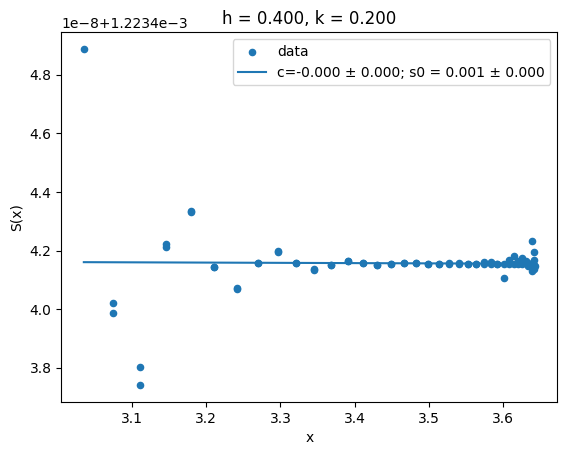

['out', '0.405', '0.200']


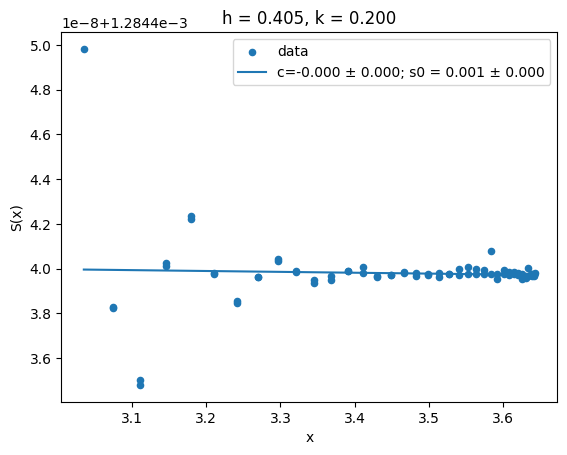

['out', '0.410', '0.200']


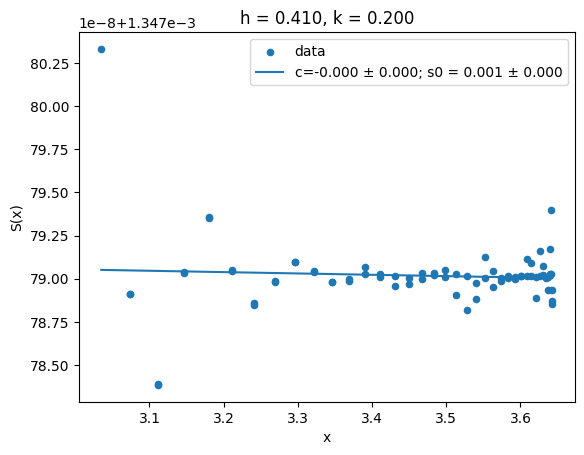

['out', '0.415', '0.200']


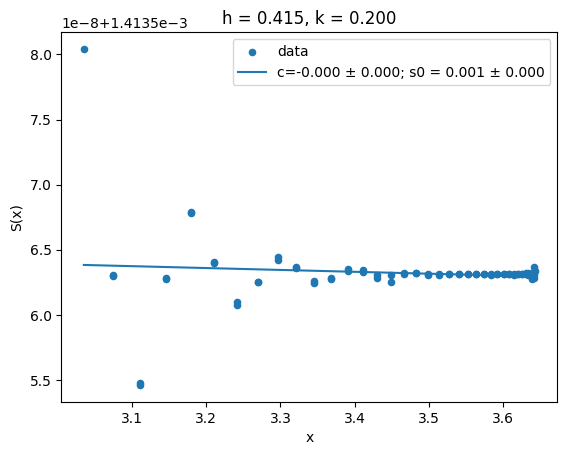

['out', '0.420', '0.200']


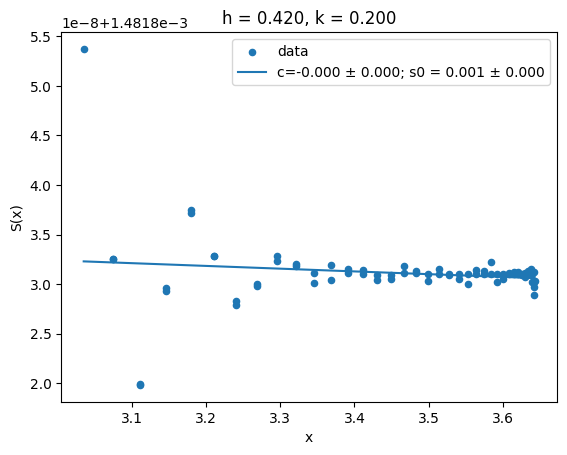

['out', '0.425', '0.200']


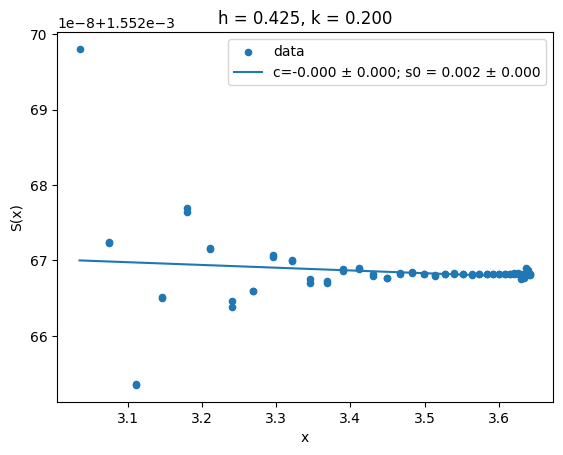

['out', '0.430', '0.200']


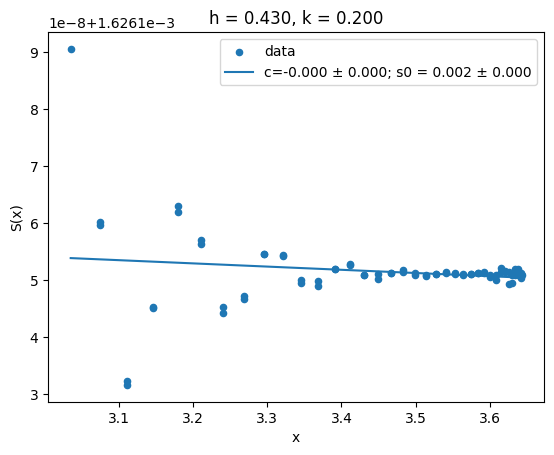

['out', '0.435', '0.200']


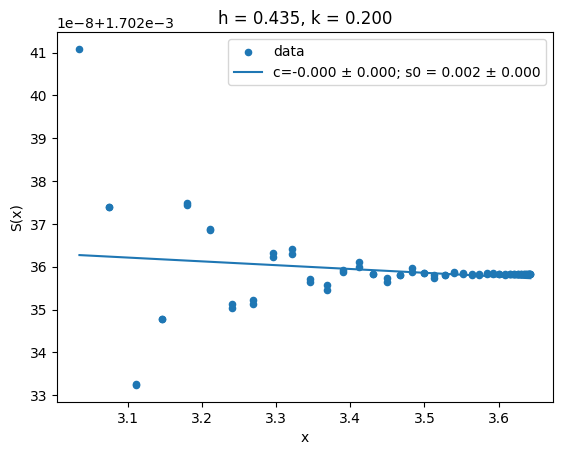

['out', '0.440', '0.200']


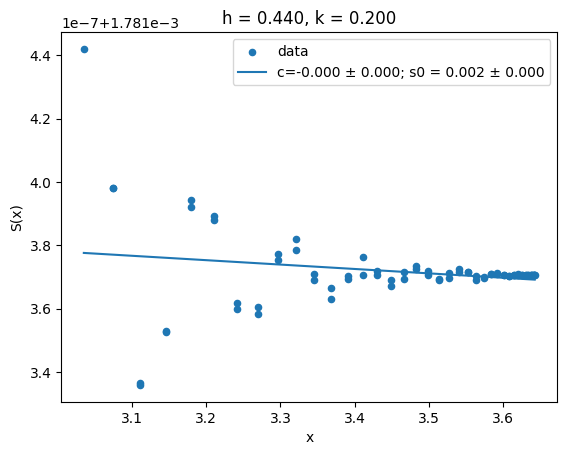

['out', '0.445', '0.200']


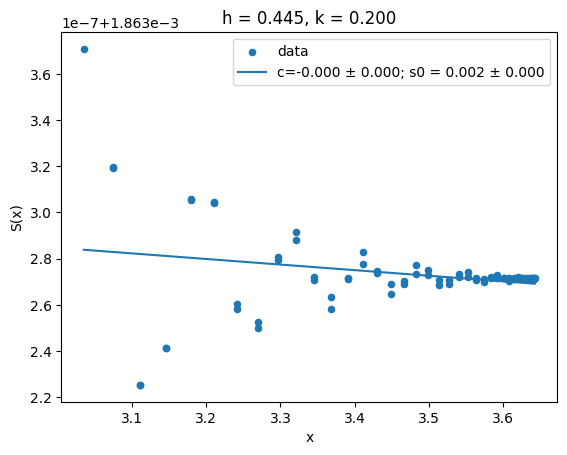

['out', '0.450', '0.200']


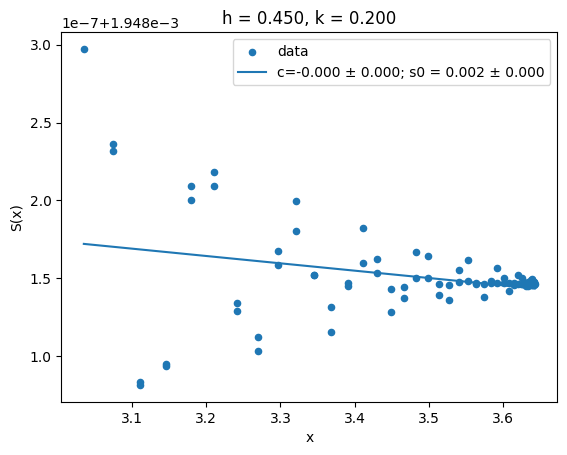

['out', '0.455', '0.200']


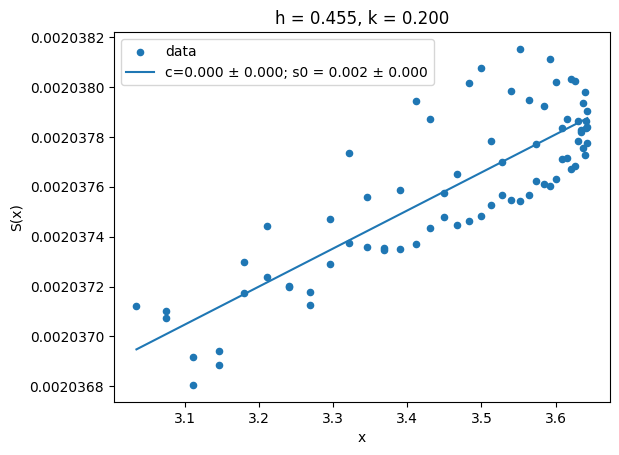

['out', '0.460', '0.200']


/tmp/ipykernel_19030/2810121215.py:26: RuntimeWarning: invalid value encountered in log
  x0 = np.log((L/np.pi) * np.sin(np.pi * x0 / L))


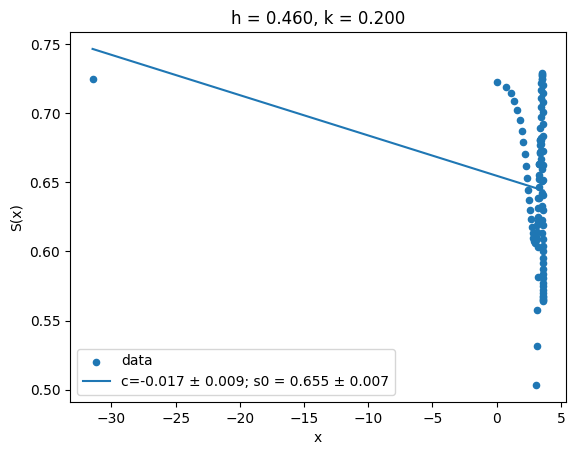

['out', '0.465', '0.200']


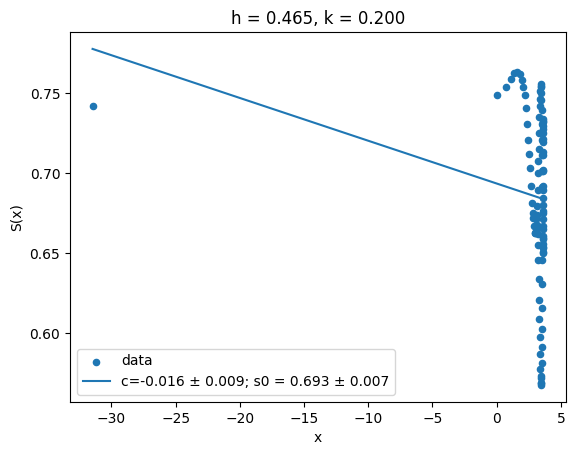

['out', '0.470', '0.200']


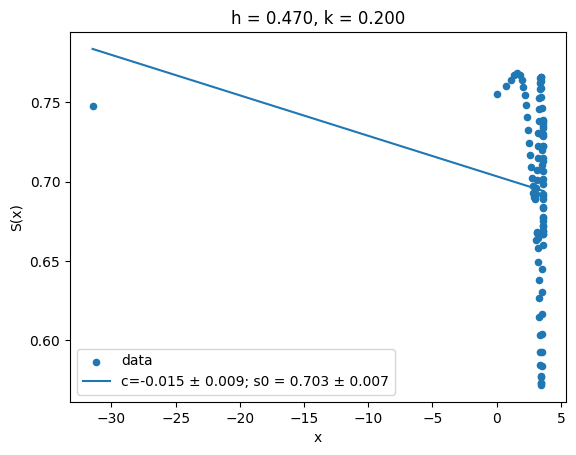

['out', '0.475', '0.200']


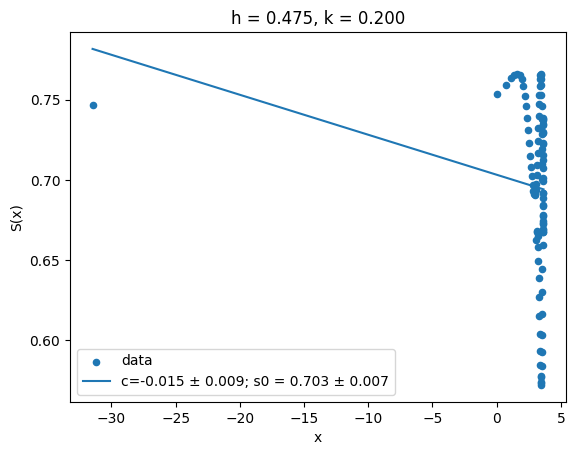

['out', '0.480', '0.200']


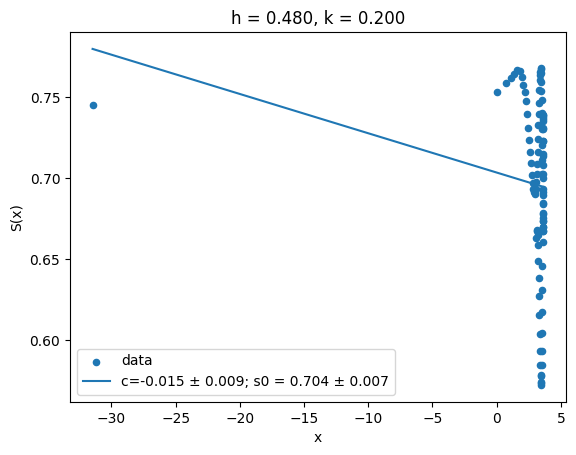

['out', '0.485', '0.200']


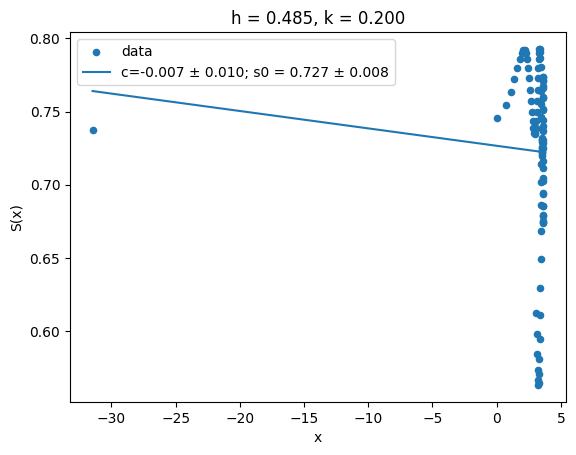

['out', '0.490', '0.200']


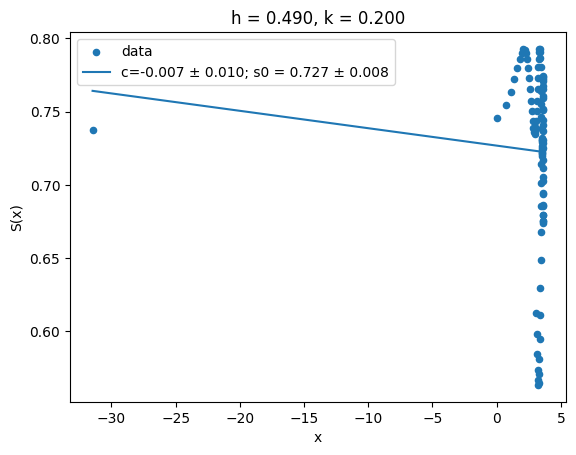

['out', '0.495', '0.200']


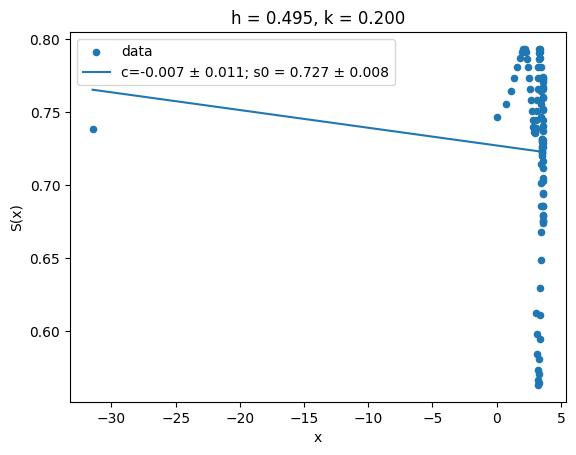

['out', '0.500', '0.200']


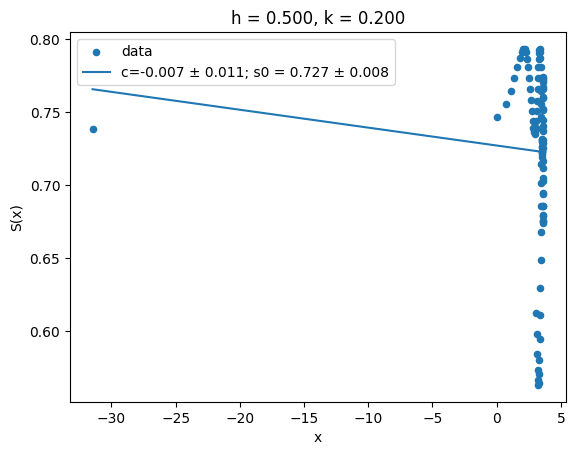

['out', '0.505', '0.200']


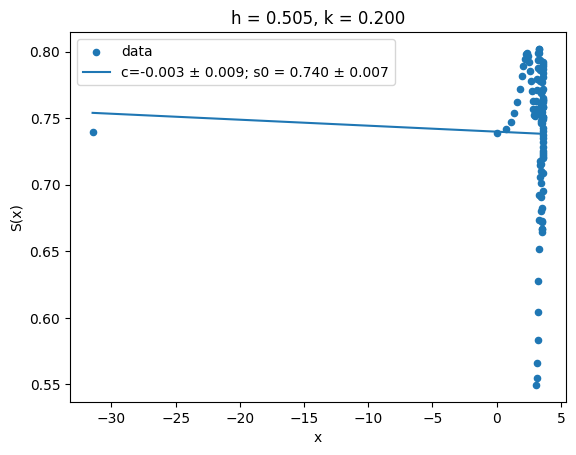

['out', '0.510', '0.200']


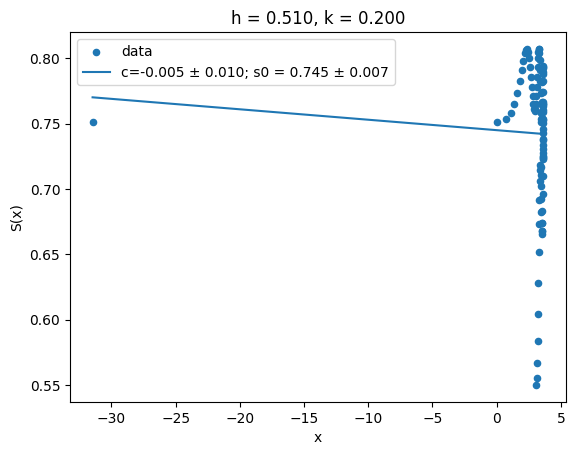

['out', '0.515', '0.200']


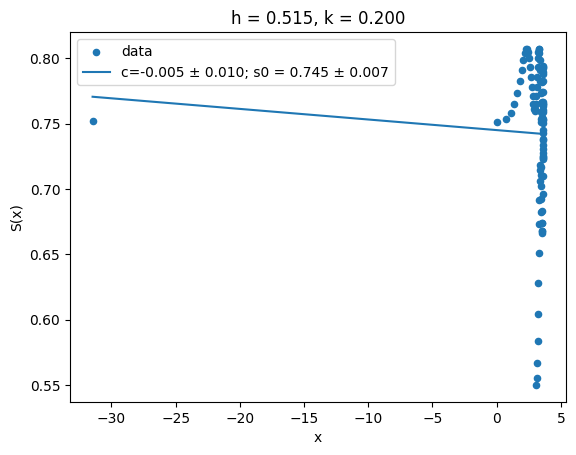

['out', '0.520', '0.200']


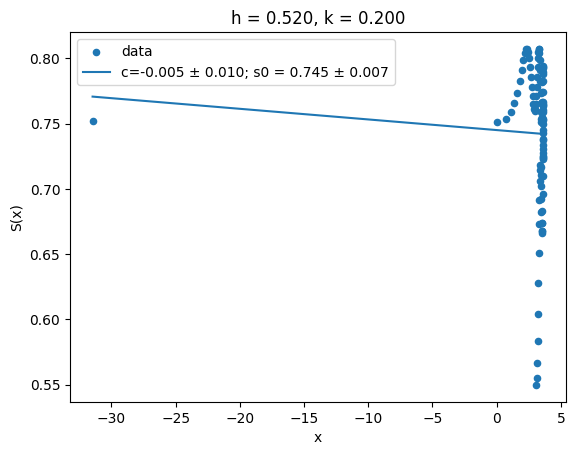

['out', '0.525', '0.200']


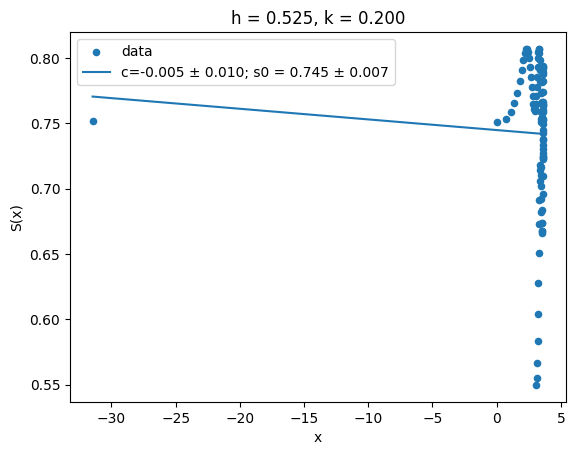

['out', '0.530', '0.200']


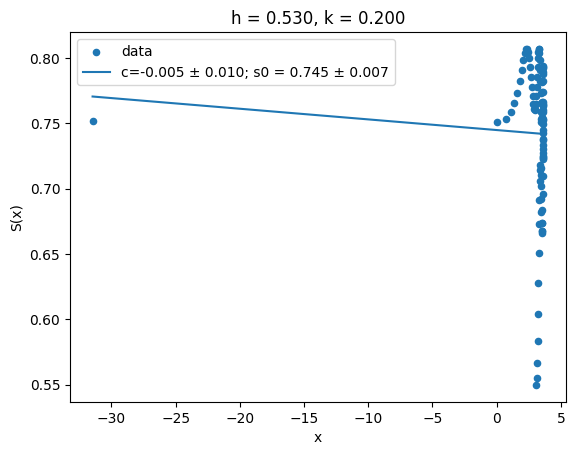

['out', '0.540', '0.200']


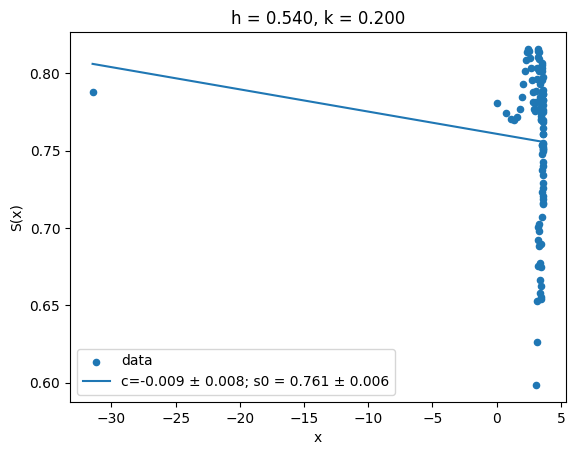

['out', '0.545', '0.200']


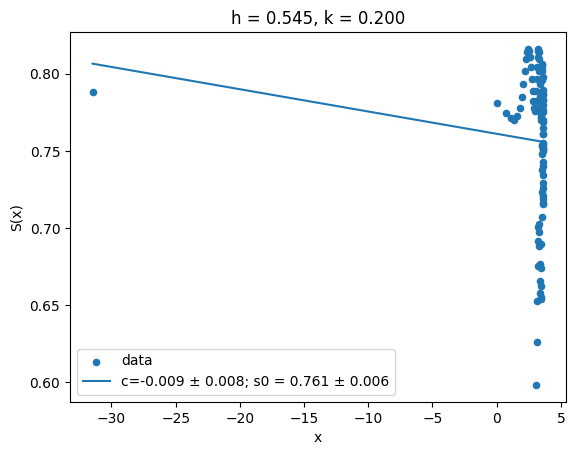

['out', '0.550', '0.200']


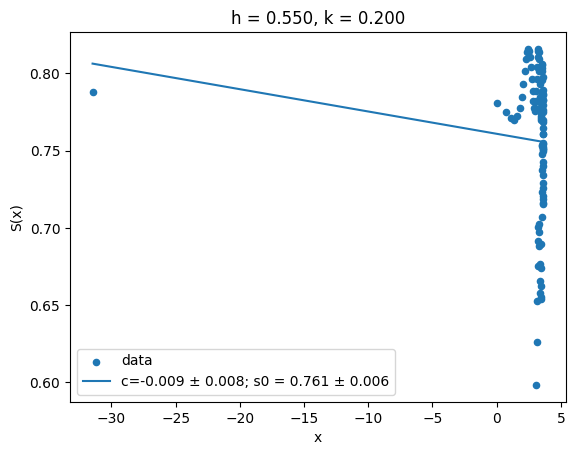

['out', '0.555', '0.200']


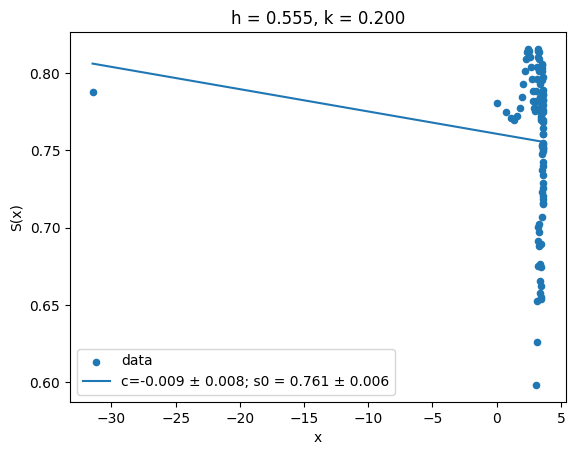

['out', '0.560', '0.200']


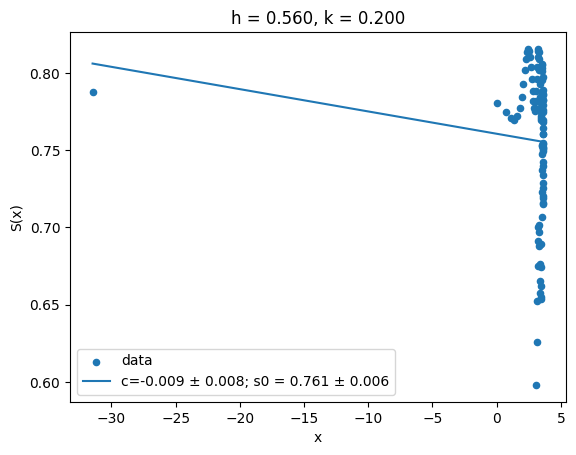

['out', '0.565', '0.200']


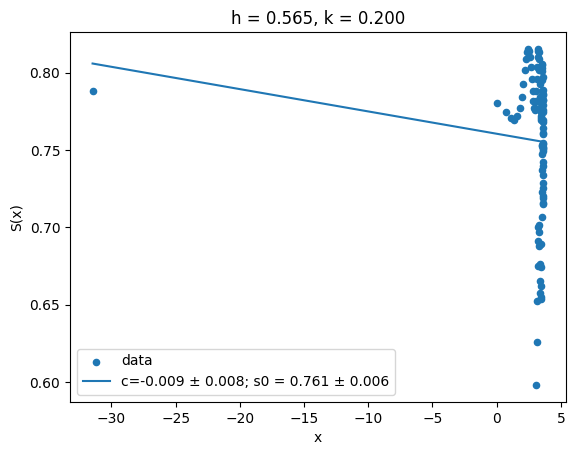

['out', '0.575', '0.200']


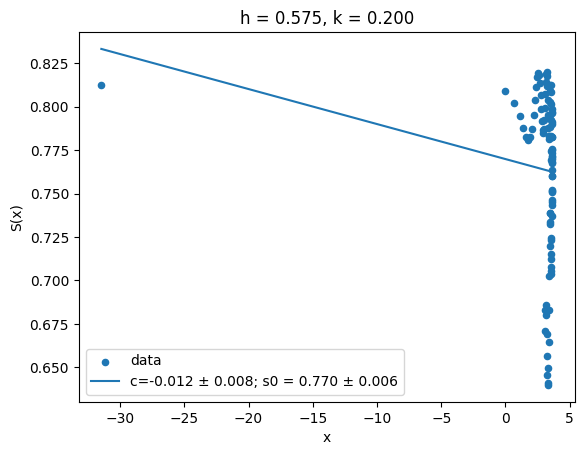

['out', '0.580', '0.200']


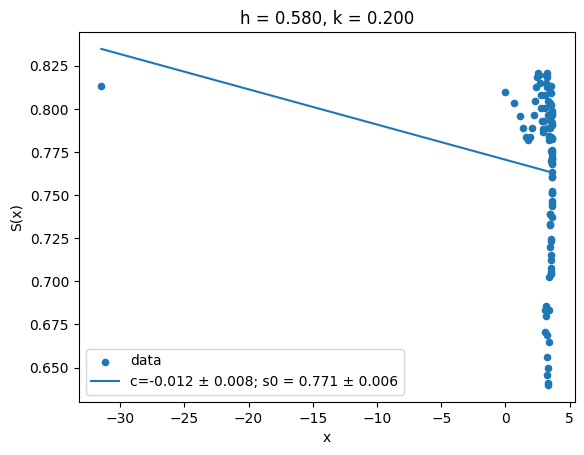

['out', '0.585', '0.200']


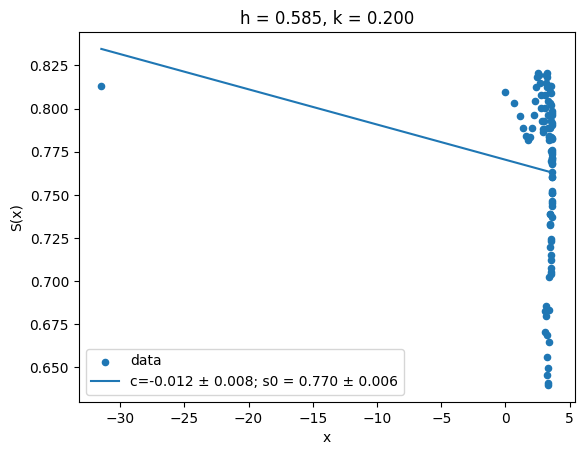

['out', '0.590', '0.200']


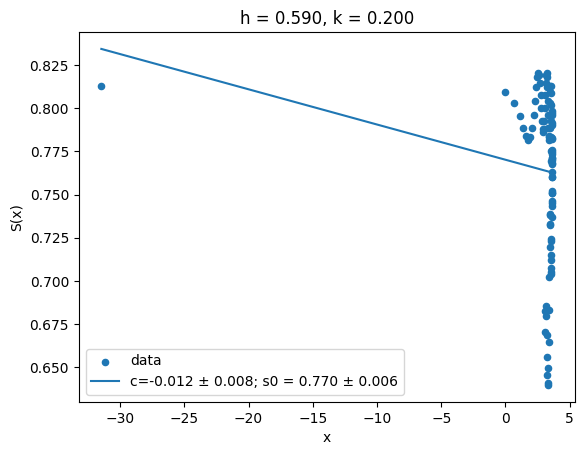

['out', '0.595', '0.200']


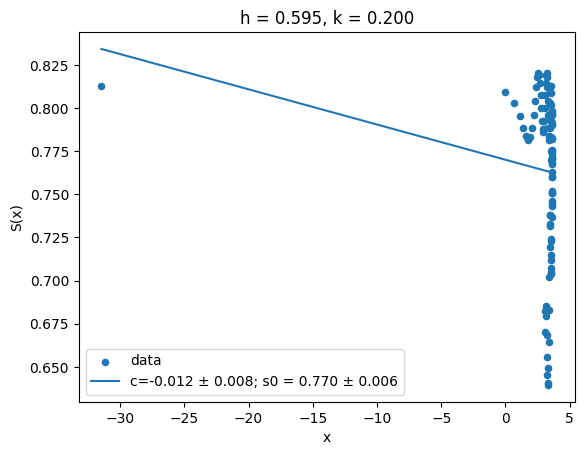

['out', '0.600', '0.200']


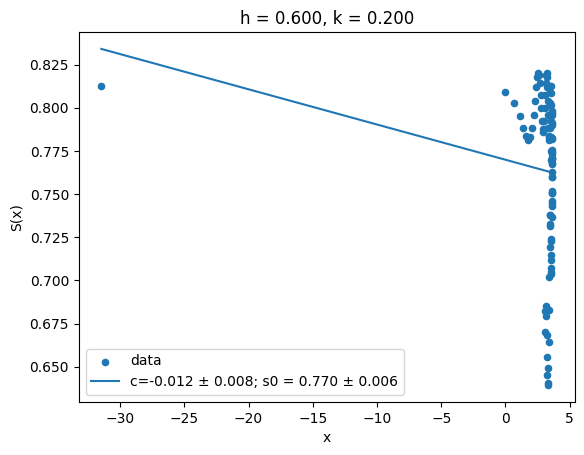

In [25]:
base_cmaps = [plt.cm.Reds]
n_shades = 1  # number of files per block

# colours
colors = []
for i in range(len(filenames)):
    block = i // n_shades              
    shade_idx = i % n_shades           
    cmap = base_cmaps[block % len(base_cmaps)]
    
    shade = 0.3 + (0.9 - 0.3) * (shade_idx / (n_shades))
    colors.append(cmap(shade))


h = []
k = []
c = []
c_err = []

for index, file in enumerate(filenames):
    print(file.split("_"))
    _, h1, k1 = file.split("_")
    S = np.loadtxt(os.path.join(path, file, "S.txt")).T
    y0 = np.array(S[2])[cut:-cut] if cut != 0  else np.array(S[2])
    x0 = np.array(S[1])[cut:-cut] if cut != 0  else np.array(S[1])
    x0 = np.log((L/np.pi) * np.sin(np.pi * x0 / L))

    zerod_out = ((np.abs(x0) > 1e-12) & (np.isfinite(x0)))
    x0 = x0[zerod_out]
    y0 = y0[zerod_out]

    popt, pcov = curve_fit(s_calabrese_cardy, x0, y0)
    perr = np.sqrt(np.diag(pcov))

    h.append(float(h1))
    k.append(float(k1))
    c.append(popt[0])
    c_err.append(np.sqrt(pcov[0][0]))

    plt.figure()
    plt.scatter(x0, y0, s=20, label="data")
    xx = np.linspace(x0.min(), x0.max(), 200)
    plt.plot(xx, s_calabrese_cardy(xx, *popt), label=f"c={popt[0]:.3f} ± {perr[0]:.3f}; s0 = {popt[1]:.3f} ± {perr[1]:.3f}")
    plt.title(f"h = {h1}, k = {k1}")
    plt.xlabel("x")
    plt.ylabel("S(x)")
    plt.legend()
    plt.show()

/tmp/ipykernel_19030/2300257307.py:25: RuntimeWarning: invalid value encountered in log
  x0 = np.log((L/np.pi) * np.sin(np.pi * x0 / L))


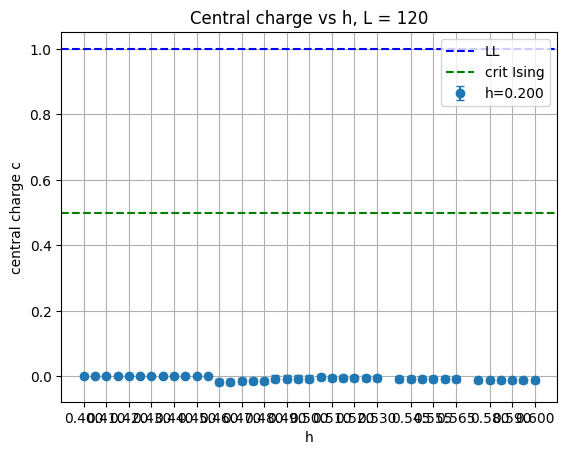

In [27]:
plt.figure()

base_cmaps = [plt.cm.Reds]
n_shades = 9  # number of files per block

# colours
colors = []
for i in range(len(filenames)):
    block = i // n_shades              
    shade_idx = i % n_shades           
    cmap = base_cmaps[block % len(base_cmaps)]
    
    shade = 0.3 + (0.9 - 0.3) * (shade_idx / (n_shades-1))
    colors.append(cmap(shade))

h = []
k = []
c = []
c_err = []
for index, file in enumerate(filenames):
    _, h1, k1 = file.split("_")
    S = np.loadtxt(os.path.join(path, file, "S.txt")).T
    y0 = np.array(S[2])[cut:-cut] if cut != 0  else np.array(S[2])
    x0 = np.array(S[1])[cut:-cut] if cut != 0  else np.array(S[1])
    x0 = np.log((L/np.pi) * np.sin(np.pi * x0 / L))

    zerod_out = ((np.abs(x0) > 1e-15) & (np.isfinite(x0)))
    x0 = x0[zerod_out]
    y0 = y0[zerod_out]

    popt, pcov = curve_fit(s_calabrese_cardy, x0, y0)
    perr = np.sqrt(np.diag(pcov))

    h.append(float(h1))
    k.append(float(k1))
    c.append(popt[0])
    c_err.append(np.sqrt(pcov[0][0]))

ks = np.array(h)
cs = np.array(c)
cs_err = np.array(c_err)
order = np.argsort(ks)
ks_s, cs_s, cs_err_s = ks[order], cs[order], cs_err[order]

plt.errorbar(ks_s, cs_s, yerr=cs_err_s, fmt='o', capsize=3, label = f"h={k1}" )
# plt.semilogx(ks_s, cs_s,  label=f"h={h1}")
plt.xlabel("h")
plt.ylabel("central charge c")
plt.xticks(ks_s[::2])
plt.grid(True)
plt.legend()

plt.title(f"Central charge vs h, L = {L}")
plt.axhline(1.0, ls = '--', c = 'blue', label = "LL")
plt.axhline(0.5, ls = '--', c = 'green', label = "crit Ising")
# plt.axvline(-0.265, ls='--', c='red', label="C/IC transition, approx")
# plt.grid()
plt.legend()
plt.show()

In [ ]:
import os

dir = os.path.join(os.getcwd(), "xi_check") 

run_h0.5_k0.105
run_h0.5_k0.165
run_h0.5_k0.115
run_h0.5_k0.190
run_h0.5_k0.150
__pycache__
run_h0.5_k0.155
run_h0.5_k0.135
utils.py
run_h0.5_k0.180
run_h0.5_k0.185
run_h0.5_k0.110
run_h0.5_k0.100
run_h0.5_k0.120
run_h0.5_k0.195
run_h0.5_k0.175
run_h0.5_k0.140
run_h0.5_k0.170
run_h0.5_k0.130
run_h0.5_k0.125
script_parallel.py
run_h0.5_k0.200
run_h0.5_k0.160
run_h0.5_k0.145


## Exact Diagonalization

In [24]:
import numpy as np
from scipy.linalg import eigh
from itertools import product
from tqdm import tqdm
import os
import shutil
from dmrg.MPS import MPS 
from dmrg.cont import CONT
from dmrg.dmrg import dmrg
from dmrg.obs import observables
import matplotlib.pyplot as plt

def build_full_H_correct(MPO_obj, L):
    """
    Build the full Hamiltonian exactly matching the MPO terms:
     J * X_i X_{i+1}
     h * Z_i
     k * X_i Y_{i+2} - k * Y_i X_{i+2}
     k * X_i Y_{i+1} Z_{i+2} - k * Z_i Y_{i+1} X_{i+2}
    """
    d = MPO_obj.d
    Id = MPO_main.Id
    X = MPO_main.X
    Y = MPO_main.Y
    Z = MPO_main.Z

    H = np.zeros((d**L, d**L), dtype=complex)

    print("Boundary polarization term")
    H_BC = np.zeros((d**L, d**L), dtype=complex)
    par = -1 ** L
    
    op = 1
    for j in range(L):
        op = np.kron(op, X if j == 0 else Id)
    H_BC += 10 * op

    op = 1
    for j in range(L):
        op = np.kron(op, X if j == L - 1 else Id)
    H_BC += par * 10 * op

    H += H_BC

    print("h term")
    for i in tqdm(range(L)):
        op = 1
        for j in range(L):
            op = np.kron(op, Z if j == i else Id)
        H += MPO_obj.h * op

    print("J term")
    for i in tqdm(range(L-1)):
        op = 1
        for j in range(L):
            op = np.kron(op, X if j==i or j==i+1 else Id)
        H += MPO_obj.J * op

    # Two-site k terms: k X_i Y_{i+2} - k Y_i X_{i+2}
    print("Two site k terms")
    for i in tqdm(range(L-2)):
        # k X_i Y_{i+2}
        op = 1
        for j in range(L):
            if j == i:
                op = np.kron(op, X)
            elif j == i+2:
                op = np.kron(op, Y)
            else:
                op = np.kron(op, Id)
        H += MPO_obj.k * op

        # - k Y_i X_{i+2}
        op = 1
        for j in range(L):
            if j == i:
                op = np.kron(op, Y)
            elif j == i+2:
                op = np.kron(op, X)
            else:
                op = np.kron(op, Id)
        H += -MPO_obj.k * op

    # Three-site k terms: k X_i Y_{i+1} Z_{i+2} - k Z_i Y_{i+1} X_{i+2}
    print("Three site k terms")
    for i in tqdm(range(L-2)):
        # k X_i Y_{i+1} Z_{i+2}
        op = 1
        for j in range(L):
            if j == i:
                op = np.kron(op, X)
            elif j == i+1:
                op = np.kron(op, Y)
            elif j == i+2:
                op = np.kron(op, Z)
            else:
                op = np.kron(op, Id)
        H += MPO_obj.k * op

        # - k Z_i Y_{i+1} X_{i+2}
        op = 1
        for j in range(L):
            if j == i:
                op = np.kron(op, Z)
            elif j == i+1:
                op = np.kron(op, Y)
            elif j == i+2:
                op = np.kron(op, X)
            else:
                op = np.kron(op, Id)
        H += -MPO_obj.k * op

    return H

def ground_state(H):
    eigvals, eigvecs = eigh(H)
    return eigvals[0].real, eigvecs[:,0]

def operator(psi, op1, i, L):
    Id = MPO_main.Id

    O = 1
    for site in range(L):
        O = np.kron(O, op1 if site == i else Id)

    return np.vdot(psi, O @ psi).real

def correlator(psi, op1, op2, i, j, L):
    Id = MPO_main.Id
    O = 1
    for site in range(L):
        if site == i:
            O = np.kron(O, op1)
        elif site == j:
            O = np.kron(O, op2)
        else:
            O = np.kron(O, Id)
    return np.vdot(psi, O @ psi).real

def connected_correlator(psi, op1, op2, i, j, L):
    ID = MPO_main.Id
    corr = correlator(psi, op1, op2, i, j, L)

    xi = operator(psi, op1, i, L)
    xj = operator(psi, op2, j, L)

    return corr - (xi* xj)

def entanglement_entropy(psi, site, L):
    """
    Compute von Neumann entropy of site 'site' with rest of chain.
    """
    d = 2
    psi = psi.reshape([d]*L)
    # Reshape to bipartition: site vs rest
    psi_mat = psi.reshape(d, -1)
    # Singular values
    s = np.linalg.svd(psi_mat, compute_uv=False)
    s = s[s>1e-12]  # ignore numerical zeros
    S = -np.sum(s**2 * np.log(s**2))
    return S

#---------DMRG------------#
class MPO_main():
    
    Id = np.identity(2)
    X = np.array([[0, 1], [1, 0]])
    Y = np.array([[0, 0-1j], [0+1j, 0]])
    Z = np.array([[1, 0], [0, -1]])
    
    def __init__(self, h, k, J, pol=None, d=2):
        self.h = h
        self.k = k
        self.J = J

        self.pol = pol
        self.d = d

    def Wl(self):
        Wleft = np.zeros((2, 2, 10),dtype='complex')
        Wleft[:, :, 0] = MPO_main.Id
        Wleft[:, :, 1] = MPO_main.X
        Wleft[:, :, 2] = MPO_main.X
        Wleft[:, :, 3] = MPO_main.Y
        Wleft[:, :, 4] = MPO_main.Z
        Wleft[:, :, 9] = self.h * MPO_main.Z

        if self.pol == 'tot':
            Wleft[:,:,9] += 10*MPO_main.X

        return Wleft
    
    def Wr(self):
        Wright = np.zeros((2, 2, 10),dtype='complex')
        Wright[:, :, 0] =  self.h * MPO_main.Z
        Wright[:, :, 1] =  self.J * MPO_main.X
        Wright[:, :, 5] =  self.k * MPO_main.Y
        Wright[:, :, 6] =  self.k * MPO_main.Z
        Wright[:, :, 7] = -self.k * MPO_main.X
        Wright[:, :, 8] = -self.k * MPO_main.X
        Wright[:, :, 9] =  MPO_main.Id

        if self.pol == 'tot':
            Wright[:,:,0] -= 10*MPO_main.X

        return Wright
    
    def mpo(self, p=None):
        MPO = np.zeros((2, 2, 10, 10),dtype='complex')

        # All interactions
        MPO[:,:,0, 0] =  MPO_main.Id
        MPO[:,:,0, 1] =  MPO_main.X
        MPO[:,:,0, 2] =  MPO_main.X
        MPO[:,:,0, 3] =  MPO_main.Y
        MPO[:,:,0, 4] =  MPO_main.Z
        MPO[:,:,0, 9] =  self.h * MPO_main.Z
        

        MPO[:,:,1, 5] =  MPO_main.Id
        MPO[:,:,2, 6] =  MPO_main.Y
        MPO[:,:,3, 7] =  MPO_main.Id
        MPO[:,:,4, 8] =  MPO_main.Y

        MPO[:,:,1, 9] =  self.J * MPO_main.X
        MPO[:,:,5, 9] =  self.k * MPO_main.Y
        MPO[:,:,6, 9] =  self.k * MPO_main.Z
        MPO[:,:,7, 9] = -self.k * MPO_main.X
        MPO[:,:,8, 9] = -self.k * MPO_main.X 
        MPO[:,:,9, 9] =  MPO_main.Id

        return MPO
    
def dmrg_main_memory(par, pol, J=1):
    results = {}  

    for h_x, k_x in par:
        key = (h_x, k_x)
        results[key] = {}

        # initialise the MPS
        mps = MPS(L)
        H_mpo = MPO_main(h=h_x, k=k_x, J=J, pol=pol)
        cont = CONT(mps=mps, H=H_mpo)

        # randomize MPS and CONT
        mps.random()
        cont.random()

        # initialize DMRG
        sys = dmrg(cont=cont, chi=10, cut=1e-12)

        # first half sweep (warm-up)
        for site, dir in mps.first_sweep():
            _, _, _ = sys.step2sites(site, dir=dir, stage="Final")

        # sweep until convergence or fixed number
        # counter = 0
        En_list = []
        print("Begin sweeping")
        for _ in tqdm(range(7)):
            j = 0
            for site, dir in mps.sweep():
                E, S, _ = sys.step2sites(site, dir=dir)
                En_list.append(E)
                j += 1
            sys.chi += 200

        results[key]['energies'] = np.array(En_list)
        print("Sweeping complete! Now onto observables")
        
        # # store observables
        # obs = observables(mps)
        # X_list = []
        # Y_list = []
        # Z_list = []
        # S_list = []
        # XX_corr = []
        # YY_corr = []
        # ZZ_corr = []

        # for site, dir in tqdm(mps.right_sweep()):
        #     E, S, _ = sys.step2sites(site, dir=dir, stage='Final')

        #     # single-site magnetizations
        #     X_list.append(obs.single_site(site, H_mpo.X).real)
        #     Y_list.append(obs.single_site(site, H_mpo.Y).real)
        #     Z_list.append(obs.single_site(site, H_mpo.Z).real)

        #     # entanglement entropy
        #     S_list.append(S)

        #     # two-point correlations
        #     XX_corr.append(obs.all_corr(None, site, string=H_mpo.Id, obs1=H_mpo.X))
        #     YY_corr.append(obs.all_corr(None, site, string=H_mpo.Id, obs1=H_mpo.Y))
        #     ZZ_corr.append(obs.all_corr(None, site, string=H_mpo.Id, obs1=H_mpo.Z))

        # results[key]['X'] = np.array(X_list)
        # results[key]['Y'] = np.array(Y_list)
        # results[key]['Z'] = np.array(Z_list)
        # results[key]['S'] = np.array(S_list)
        # results[key]['XX'] = XX_corr
        # results[key]['YY'] = YY_corr
        # results[key]['ZZ'] = ZZ_corr

        # print(f'Parameter ({h_x:.3f}, {k_x:.3f}) done!')

    return results



In [26]:
# Define params
L = 9
h, k, J = 1, 0, 1

def check_energies(h, k, J):
    # DMRG
    results = dmrg_main_memory([(h, k)], 'tot', J=J)  # open boundary conditions
    E_DMRG = results[(h, k)]['energies'][-1]

    # ED
    mpo = MPO_main(h=h, k=k, J=J)
    H = build_full_H_correct(mpo, L)
    E_ED, psi0 = ground_state(H)

    print("\n\n Ground state energy comaprison")
    print(f"(DMRG): {E_DMRG}")
    print(f"(ED): {E_ED}")
    print(f"\nDegree of error: {np.log10(np.abs(E_ED/E_DMRG)-1)}")

check_energies(h, k, J)

# # Check for 10x energy
# h *= 10
# J *= 10
# k *= 10
# check_energies(h, k, J)

Begin sweeping


100%|██████████| 7/7 [00:02<00:00,  2.38it/s]


Sweeping complete! Now onto observables
Boundary polarization term
h term


100%|██████████| 9/9 [00:00<00:00, 126.19it/s]


J term


...

Two site k terms


100%|██████████| 7/7 [00:00<00:00, 61.52it/s]


Three site k terms


100%|██████████| 7/7 [00:00<00:00, 67.05it/s]




 Ground state energy comaprison
(DMRG): -29.56190034015965
(ED): -29.561900340180497

Degree of error: -12.151679280771964
